## EDA Bookmark 1 — Load & Overview

In [304]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

import plotly.io as pio
pio.templates.default = "plotly_white"

In [305]:
# Load dataset

DATA_PATH = "../../data/processed/phone_specs_preprocessed.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(3)

Dataset loaded: 411 rows x 30 columns


,product_name,brand,url,price_vnd,price_segment,promotion,phone_type,os_family,os_version,chip_name,chip_brand,screen_size_inch,panel,panel_group,refresh_rate_hz,resolution_width,resolution_height,resolution_total_pixels,ram_gb,storage_gb,battery_mah,fast_charge_w,front_camera_mp,rear_main_camera_mp,rear_camera_count,max_video_resolution,fps_at_max_resolution,video_resolution_rank,weight_g,ip_status
0,vivo Y28 8GB 128GB,Vivo,https://cellphones.com.vn/dien-thoai-vivo-y28....,5790000,mid,Tiết kiệm lên đến 58.000đ cho Smember,smartphone,Android,14.00,Helio G85 (12nm),MediaTek,6.68,LCD,LCD,90.00,720.00,1608.00,1157760.00,8.00,128.00,6000.00,44.00,8.00,50.00,2.00,1080p,30.00,2,199.00,1
1,Samsung Galaxy A36 5G 8GB 128GB,Samsung,https://cellphones.com.vn/dien-thoai-samsung-g...,7490000,mid,Tiết kiệm lên đến 75.000đ cho Smember | Giảm 5...,smartphone,Android,NaN,Snapdragon 6 Gen 3,Snapdragon,6.70,Super AMOLED,AMOLED,120.00,1080.00,2340.00,2527200.00,8.00,128.00,5000.00,45.00,12.00,50.00,3.00,4K,30.00,4,195.00,1
2,Masstel izi T8,Masstel,https://cellphones.com.vn/dien-thoai-masstel-i...,530000,budget,Tiết kiệm lên đến 5.000đ cho Smember,feature_phone,Unknown,NaN,ASR3603S,ASR,2.40,Unknown,Unknown,NaN,240.00,320.00,76800.00,NaN,NaN,2300.00,NaN,NaN,NaN,NaN,Unknown,NaN,0,NaN,0


In [306]:
# Drop smartphones that have too many missing KBSR feature values
#
# Feature phones are kept as-is - they naturally lack many specs
# (no resolution, no refresh rate, etc.) by design, not by data error.
# Dropping them based on nulls would be misleading.
#
# For smartphones: >= 5 nulls across 16 core KBSR columns means
# the phone lacks enough spec data for the recommender to profile it.

KBSR_COLS = [
    "price_vnd", "screen_size_inch", "refresh_rate_hz",
    "resolution_width", "resolution_height", "resolution_total_pixels",
    "ram_gb", "storage_gb", "battery_mah", "fast_charge_w",
    "front_camera_mp", "rear_main_camera_mp", "rear_camera_count",
    "weight_g", "video_resolution_rank", "ip_status",
]

NULL_THRESHOLD = 5

smartphone_mask = df["phone_type"] == "smartphone"
null_per_row    = df[KBSR_COLS].isna().sum(axis=1)

drop_mask  = smartphone_mask & (null_per_row >= NULL_THRESHOLD)
dropped_df = df[drop_mask].copy()
df         = df[~drop_mask].reset_index(drop=True)

print(f"Dropped {len(dropped_df)} smartphones with >= {NULL_THRESHOLD} null KBSR columns.")
print(f"Remaining : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"  smartphone   : {(df['phone_type'] == 'smartphone').sum()}")
print(f"  feature_phone: {(df['phone_type'] == 'feature_phone').sum()}")
print()
print("Dropped smartphones:")
display(
    dropped_df[["product_name", "brand"]]
    .assign(null_count=null_per_row[drop_mask].values)
    .sort_values("null_count", ascending=False)
    .reset_index(drop=True)
)

Dropped 7 smartphones with >= 5 null KBSR columns.
Remaining : 404 rows x 30 columns
  smartphone   : 387
  feature_phone: 16

Dropped smartphones:


,product_name,brand,null_count
0,Samsung Galaxy S 2019,Samsung,10
1,Vsmart Joy 2 Plus,Vsmart,8
2,Điện thoại Meizu Mblu 21 4GB 64GB,Meizu,6
3,TECNO Spark 50 4GB 128GB,Tecno,6
4,Vsmart Joy 2 Plus 2GB,Vsmart,6
5,Điện thoại Meizu Mblu 21 6GB 128GB,Meizu,6
6,Điện thoại Nubia A36 4GB 64GB,Nubia,5


In [307]:
# Schema overview: dtype, missing %, unique count, sample value per column
schema = pd.DataFrame({
    "dtype"       : df.dtypes,
    "non_null"    : df.notna().sum(),
    "missing"     : df.isna().sum(),
    "missing_pct" : (df.isna().mean() * 100).round(2),
    "nunique"     : df.nunique(),
    "sample"      : [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})

print("=" * 60)
print("SCHEMA OVERVIEW")
print("=" * 60)
display(schema)

SCHEMA OVERVIEW


,dtype,non_null,missing,missing_pct,nunique,sample
product_name,str,404,0,0.00,404,vivo Y28 8GB 128GB
brand,str,404,0,0.00,22,Vivo
url,str,404,0,0.00,404,https://cellphones.com.vn/dien-thoai-vivo-y28....
price_vnd,int64,404,0,0.00,216,5790000
price_segment,str,404,0,0.00,4,mid
promotion,str,384,20,4.95,275,Tiết kiệm lên đến 58.000đ cho Smember
phone_type,str,404,0,0.00,3,smartphone
os_family,str,404,0,0.00,4,Android
os_version,float64,313,91,22.52,13,14.00
chip_name,str,404,0,0.00,215,Helio G85 (12nm)


In [308]:
# Descriptive statistics for numeric columns (count, mean, std, min/max, quartiles)
NUMERIC_COLS = df.select_dtypes(include="number").columns.tolist()

print("=" * 60)
print("NUMERIC COLUMNS SUMMARY")
print("=" * 60)
display(df[NUMERIC_COLS].describe().T.round(2))

NUMERIC COLUMNS SUMMARY


,count,mean,std,min,25%,50%,75%,max
price_vnd,404.00,13750581.68,11880862.72,420000.00,4497500.00,8660000.00,22315000.00,63990000.00
os_version,313.00,14.39,3.25,8.10,13.00,14.00,15.00,26.00
screen_size_inch,402.00,6.46,0.93,1.77,6.50,6.70,6.77,8.12
refresh_rate_hz,361.00,109.88,21.70,60.00,90.00,120.00,120.00,165.00
resolution_width,368.00,1099.38,289.70,128.00,1080.00,1080.00,1256.00,2268.00
resolution_height,368.00,2347.46,542.05,160.00,2340.00,2400.00,2712.00,3216.00
resolution_total_pixels,368.00,2710025.00,1060719.48,20480.00,2527200.00,2600640.00,3329280.00,5533920.00
ram_gb,362.00,8.29,3.33,0.05,6.00,8.00,12.00,16.00
storage_gb,398.00,268.55,233.55,0.12,128.00,256.00,256.00,2048.00
battery_mah,352.00,4829.85,1214.83,323.00,4500.00,5000.00,5200.00,8300.00


In [309]:
# Value counts for categorical columns — top 5 values per column
CAT_COLS = df.select_dtypes(include="object").columns.tolist()

print("=" * 60)
print("CATEGORICAL COLUMNS SUMMARY")
print("=" * 60)

for col in CAT_COLS:
    vc = df[col].value_counts()
    print(f"\n▸ {col}  ({df[col].nunique()} unique, {df[col].isna().sum()} missing)")
    print(vc.head(5).to_string())

CATEGORICAL COLUMNS SUMMARY

▸ product_name  (404 unique, 0 missing)
product_name
vivo Y28 8GB 128GB                 1
Samsung Galaxy A36 5G 8GB 128GB    1
Masstel izi T8                     1
Samsung Galaxy A21s 6GB            1
Samsung Galaxy S20                 1

▸ brand  (22 unique, 0 missing)
brand
Samsung    100
Apple       69
OPPO        53
Xiaomi      53
Nubia       27

▸ url  (404 unique, 0 missing)
url
https://cellphones.com.vn/dien-thoai-vivo-y28.html              1
https://cellphones.com.vn/dien-thoai-samsung-galaxy-a36.html    1
https://cellphones.com.vn/dien-thoai-masstel-izi-t8.html        1
https://cellphones.com.vn/samsung-galaxy-a21s-6gb.html          1
https://cellphones.com.vn/samsung-galaxy-s20.html               1

▸ price_segment  (4 unique, 0 missing)
price_segment
budget      121
flagship    112
mid          97
high         74

▸ promotion  (275 unique, 20 missing)
promotion
Tiết kiệm lên đến 5.000đ cho Smember     7
Tiết kiệm lên đến 50.000đ cho Smember    5


C:\Users\Gato419\AppData\Local\Temp\ipykernel_23752\4050402150.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CAT_COLS = df.select_dtypes(include="object").columns.tolist()


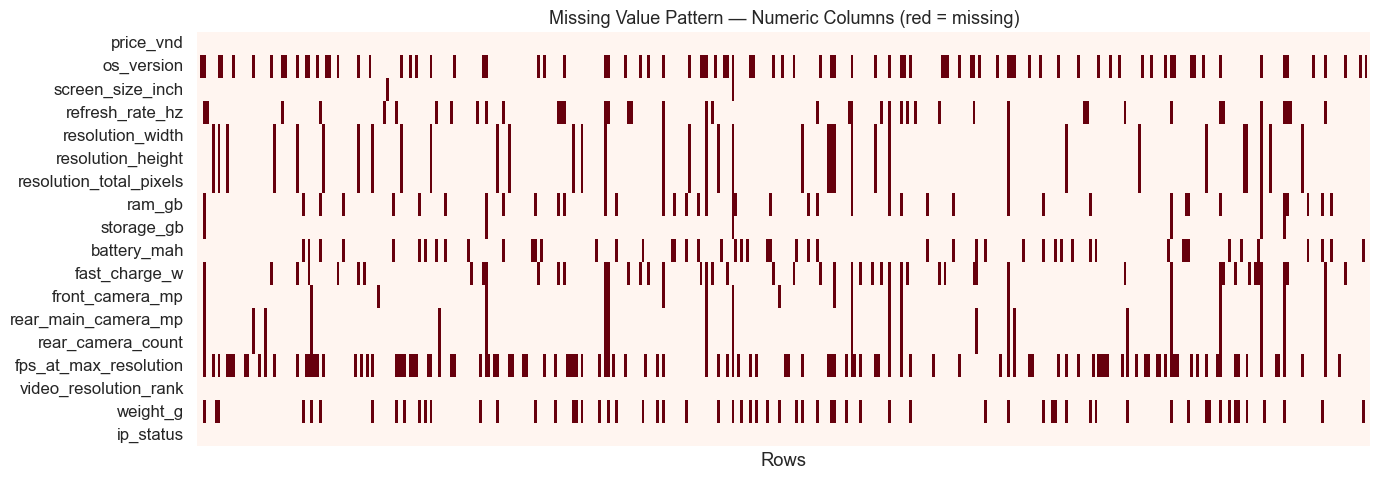

In [310]:
# Heatmap: missing value pattern across numeric columns (red = missing)
missing_matrix = df[NUMERIC_COLS].isna().astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    missing_matrix.T,
    cmap="Reds",
    cbar=False,
    yticklabels=NUMERIC_COLS,
    xticklabels=False,
    ax=ax,
)
ax.set_title("Missing Value Pattern — Numeric Columns (red = missing)", fontsize=13)
ax.set_xlabel("Rows")
plt.tight_layout()
plt.show()

In [311]:
# Interactive bar chart: missing rate (%) per column, sorted ascending
missing_df = (
    df.isna().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=True)
)

fig = px.bar(
    missing_df,
    x="missing_pct",
    y="column",
    orientation="h",
    text="missing_count",
    labels={"missing_pct": "Missing (%)", "column": "Column"},
    title="Missing Values by Column",
    color="missing_pct",
    color_continuous_scale="Reds",
)
fig.update_traces(textposition="outside")
fig.update_layout(coloraxis_showscale=False, height=500)
fig.show()

In [312]:
# Summary check for EDA 1: row/column count, missing, duplicates, type breakdown
print("=" * 60)
print("CHECK EDA 1 — DATASET OVERVIEW")
print("=" * 60)
print(f"  Total rows          : {df.shape[0]}")
print(f"  Total columns       : {df.shape[1]}")
print(f"  Numeric columns     : {len(NUMERIC_COLS)}")
print(f"  Categorical columns : {len(CAT_COLS)}")
print(f"  Columns with missing: {(df.isna().sum() > 0).sum()}")
print(f"  Duplicate rows      : {df.duplicated().sum()}")
print(f"\n  phone_type breakdown:")
print(df["phone_type"].value_counts().to_string())
print(f"\n  price_segment breakdown:")
print(df["price_segment"].value_counts().to_string())
print("=" * 60)

CHECK EDA 1 — DATASET OVERVIEW
  Total rows          : 404
  Total columns       : 30
  Numeric columns     : 18
  Categorical columns : 12
  Columns with missing: 16
  Duplicate rows      : 0

  phone_type breakdown:
phone_type
smartphone       387
feature_phone     16
Unknown            1

  price_segment breakdown:
price_segment
budget      121
flagship    112
mid          97
high         74


## Bookmark EDA 2 — Price Distribution

Analyze the distribution of phone prices across segments and brands.

In [313]:
# Define segment order and color palette — reused across all EDA 2+ charts
SEGMENT_ORDER = ["budget", "mid", "high", "flagship"]

SEGMENT_COLORS = {
    "budget"  : "#4CAF50",
    "mid"     : "#2196F3",
    "high"    : "#FF9800",
    "flagship": "#E91E63",
}

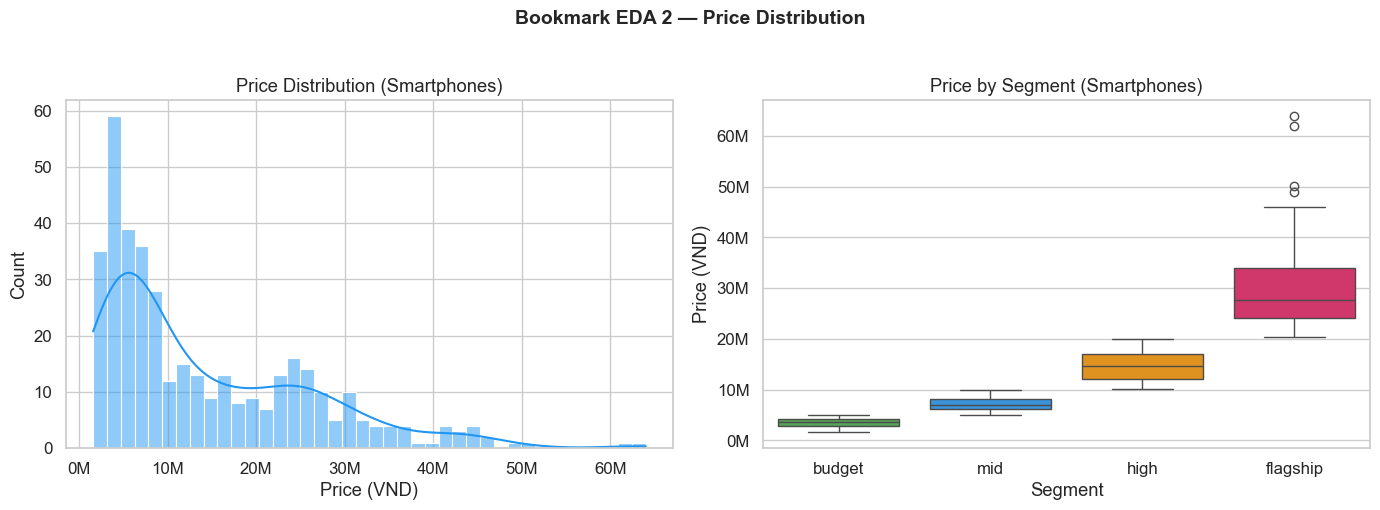

In [314]:
# Price histogram + KDE (left) and boxplot by segment (right) — smartphones only
smartphone_df = df[df["phone_type"] == "smartphone"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=smartphone_df, x="price_vnd", bins=40, kde=True, color="#2196F3", ax=axes[0])
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))
axes[0].set_title("Price Distribution (Smartphones)")
axes[0].set_xlabel("Price (VND)")
axes[0].set_ylabel("Count")

sns.boxplot(
    data=smartphone_df, x="price_segment", y="price_vnd",
    order=SEGMENT_ORDER, palette=SEGMENT_COLORS,
    hue="price_segment", legend=False,   
    ax=axes[1],
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y/1_000_000:.0f}M"))
axes[1].set_title("Price by Segment (Smartphones)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Price (VND)")

plt.suptitle("Bookmark EDA 2 — Price Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

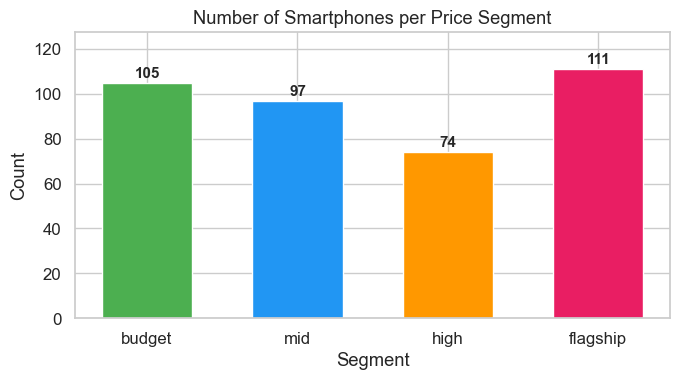

In [315]:
# Bar chart: smartphone count per price segment
seg_counts = (
    smartphone_df["price_segment"]
    .value_counts()
    .reindex(SEGMENT_ORDER)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    seg_counts.index,
    seg_counts.values,
    color=[SEGMENT_COLORS[s] for s in seg_counts.index],
    edgecolor="white",
    width=0.6,
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

ax.set_title("Number of Smartphones per Price Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Count")
ax.set_ylim(0, seg_counts.max() * 1.15)
plt.tight_layout()
plt.show()

In [316]:
# Price range table: min / median / max per segment (formatted in millions VND)
seg_stats = (
    smartphone_df
    .groupby("price_segment")["price_vnd"]
    .agg(["min", "median", "max"])
    .reindex(SEGMENT_ORDER)
    .map(lambda x: f"{x/1_000_000:.2f}M")
)
seg_stats.index.name = "segment"
seg_stats.columns = ["min_price", "median_price", "max_price"]

print("=" * 50)
print("PRICE RANGE PER SEGMENT (VND)")
print("=" * 50)
print(seg_stats.to_string())

PRICE RANGE PER SEGMENT (VND)
         min_price median_price max_price
segment                                  
budget       1.59M        3.59M     4.99M
mid          5.09M        7.06M     9.99M
high        10.10M       14.74M    19.99M
flagship    20.45M       27.59M    63.99M


In [317]:
# Interactive boxplot: price distribution by brand (brands with ≥ 5 phones, sorted by median)
brand_counts = smartphone_df["brand"].value_counts()
major_brands = brand_counts[brand_counts >= 5].index.tolist()
brand_df = smartphone_df[smartphone_df["brand"].isin(major_brands)].copy()

brand_order = (
    brand_df.groupby("brand")["price_vnd"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig = px.box(
    brand_df,
    x="brand",
    y="price_vnd",
    category_orders={"brand": brand_order},
    color="brand",
    title="Price Distribution by Brand (brands with ≥ 5 products)",
    labels={"price_vnd": "Price (VND)", "brand": "Brand"},
    points="outliers",
)
fig.update_layout(height=500, showlegend=False, yaxis_tickformat=",")
fig.show()

In [318]:
# Interactive strip chart: every phone as a dot, hover to see name + brand + price
fig = px.strip(
    smartphone_df,
    x="price_segment",
    y="price_vnd",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    hover_data={"product_name": True, "brand": True, "price_vnd": True},
    title="All Smartphones — Price by Segment (hover for details)",
    labels={"price_vnd": "Price (VND)", "price_segment": "Segment"},
)
fig.update_yaxes(tickformat=",")
fig.update_layout(height=520, showlegend=False)
fig.show()

In [319]:
# Summary check for EDA 2: price range, median, per-segment stats, top 3 most expensive
print("=" * 55)
print("CHECK EDA 2 — PRICE DISTRIBUTION SUMMARY")
print("=" * 55)

print(f"\n  Smartphones analyzed : {len(smartphone_df)}")
print(f"\n  Overall price range  : "
      f"{smartphone_df['price_vnd'].min()/1e6:.2f}M "
      f"— {smartphone_df['price_vnd'].max()/1e6:.2f}M VND")
print(f"  Median price         : "
      f"{smartphone_df['price_vnd'].median()/1e6:.2f}M VND")

print(f"\n  Segment breakdown:")
for seg in SEGMENT_ORDER:
    seg_data = smartphone_df[smartphone_df["price_segment"] == seg]["price_vnd"]
    print(
        f"    {seg:<8} — {len(seg_data):>3} phones | "
        f"median {seg_data.median()/1e6:.1f}M | "
        f"range {seg_data.min()/1e6:.1f}M – {seg_data.max()/1e6:.1f}M"
    )

print(f"\n  Top 3 most expensive smartphones:")
top3 = smartphone_df.nlargest(3, "price_vnd")[["product_name", "brand", "price_vnd"]]
for _, row in top3.iterrows():
    print(f"    • {row['product_name']} — {row['price_vnd']/1e6:.2f}M VND")

print("=" * 55)

CHECK EDA 2 — PRICE DISTRIBUTION SUMMARY

  Smartphones analyzed : 387

  Overall price range  : 1.59M — 63.99M VND
  Median price         : 8.99M VND

  Segment breakdown:
    budget   — 105 phones | median 3.6M | range 1.6M – 5.0M
    mid      —  97 phones | median 7.1M | range 5.1M – 10.0M
    high     —  74 phones | median 14.7M | range 10.1M – 20.0M
    flagship — 111 phones | median 27.6M | range 20.4M – 64.0M

  Top 3 most expensive smartphones:
    • OPPO Find N6 16GB 512GB — 63.99M VND
    • iPhone 17 Pro Max 2TB | Chính hãng — 61.99M VND
    • iPhone 17 Pro Max 1TB | Chính hãng — 50.09M VND


## Bookmark EDA 3 — Specs Distribution

Analyze the distribution of key hardware specs:
RAM, storage, battery, screen size, and refresh rate.

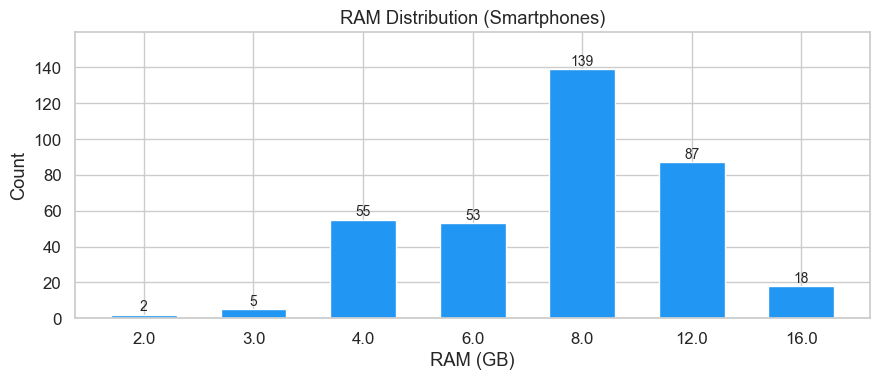

In [320]:
# Matplotlib: countplot-style bar — RAM is discrete, bar chart fits better than KDE
ram_counts = (
    smartphone_df["ram_gb"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(
    ram_counts.index.astype(str),
    ram_counts.values,
    color="#2196F3",
    edgecolor="white",
    width=0.6,
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.5,
        str(int(h)),
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("RAM Distribution (Smartphones)")
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Count")
ax.set_ylim(0, ram_counts.max() * 1.15)
plt.tight_layout()
plt.show()

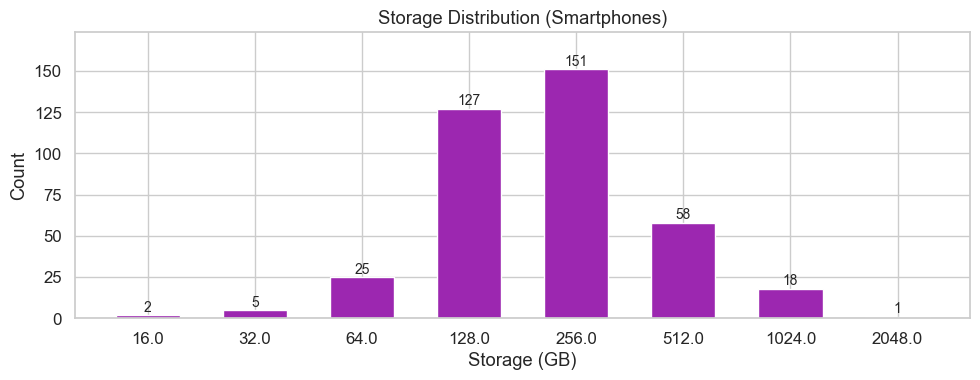

In [321]:
# Matplotlib: same style as RAM — storage is also discrete
storage_counts = (
    smartphone_df["storage_gb"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    storage_counts.index.astype(str),
    storage_counts.values,
    color="#9C27B0",
    edgecolor="white",
    width=0.6,
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.5,
        str(int(h)),
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("Storage Distribution (Smartphones)")
ax.set_xlabel("Storage (GB)")
ax.set_ylabel("Count")
ax.set_ylim(0, storage_counts.max() * 1.15)
plt.tight_layout()
plt.show()

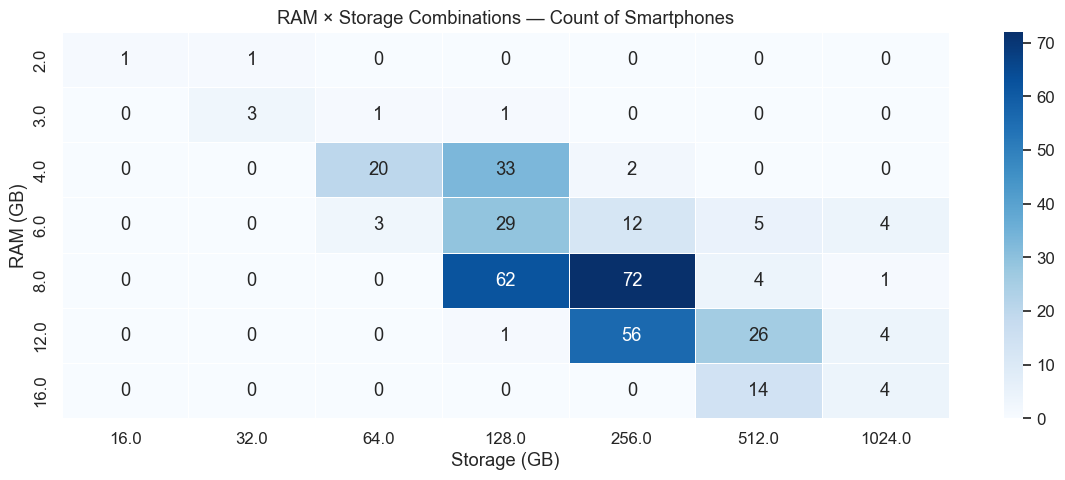

In [322]:
# Seaborn: heatmap — show which RAM/storage combinations are most common
ram_storage = (
    smartphone_df
    .groupby(["ram_gb", "storage_gb"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    ram_storage,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("RAM × Storage Combinations — Count of Smartphones")
ax.set_xlabel("Storage (GB)")
ax.set_ylabel("RAM (GB)")
plt.tight_layout()
plt.show()

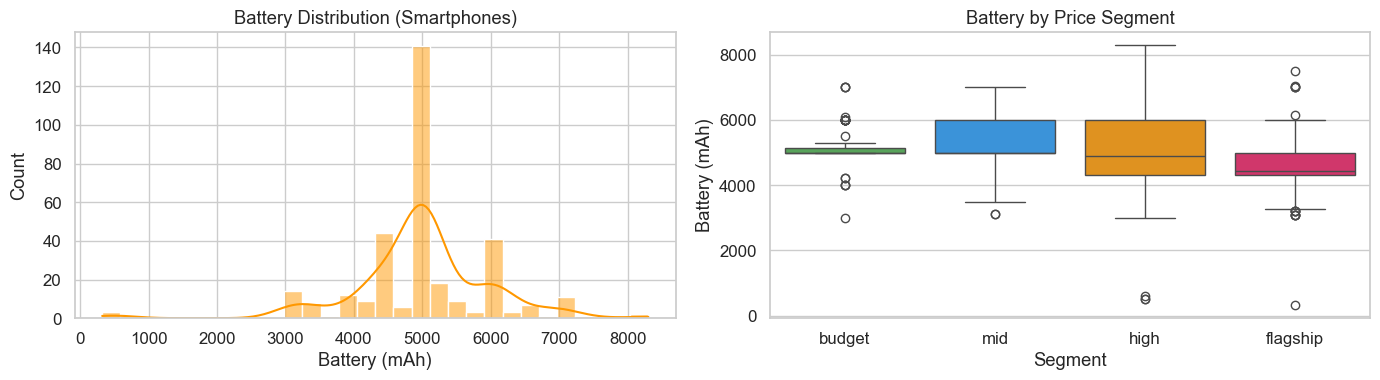

In [323]:
# Seaborn: histogram + KDE — battery is continuous, distribution shape matters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: overall distribution
sns.histplot(
    data=smartphone_df,
    x="battery_mah",
    bins=30,
    kde=True,
    color="#FF9800",
    ax=axes[0],
)
axes[0].set_title("Battery Distribution (Smartphones)")
axes[0].set_xlabel("Battery (mAh)")
axes[0].set_ylabel("Count")

# Right: battery by price segment — does premium = smaller battery?
sns.boxplot(
    data=smartphone_df, x="price_segment", y="battery_mah",
    order=SEGMENT_ORDER, palette=SEGMENT_COLORS,
    hue="price_segment", legend=False,
    ax=axes[1],
)
axes[1].set_title("Battery by Price Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Battery (mAh)")

plt.tight_layout()
plt.show()

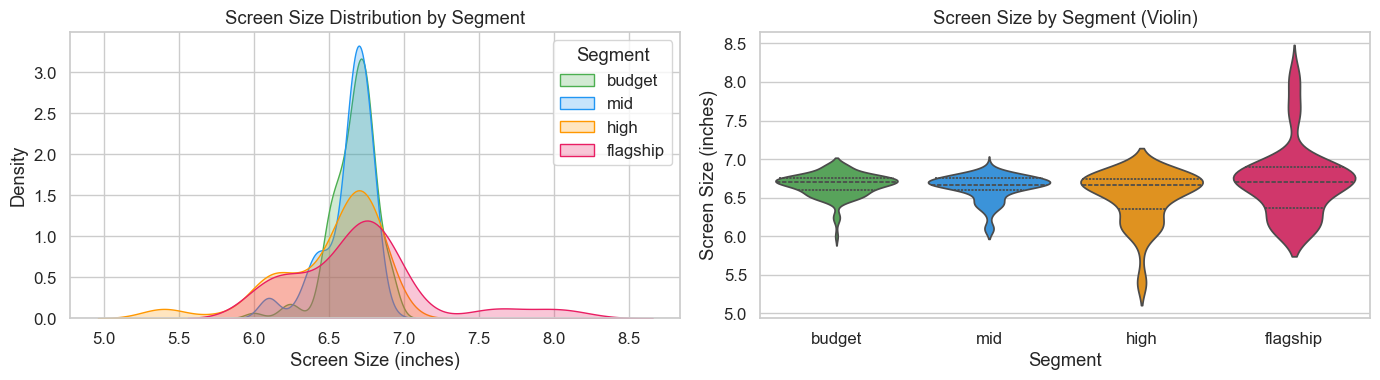

In [324]:
# Seaborn: KDE by segment — screen size is continuous, show overlap between segments
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per segment
for seg in SEGMENT_ORDER:
    seg_data = smartphone_df[smartphone_df["price_segment"] == seg]["screen_size_inch"].dropna()
    sns.kdeplot(seg_data, label=seg, color=SEGMENT_COLORS[seg], fill=True, alpha=0.25, ax=axes[0])

axes[0].set_title("Screen Size Distribution by Segment")
axes[0].set_xlabel("Screen Size (inches)")
axes[0].set_ylabel("Density")
axes[0].legend(title="Segment")

# Right: violin plot — show full distribution shape per segment
sns.violinplot(
    data=smartphone_df, x="price_segment", y="screen_size_inch",
    order=SEGMENT_ORDER, palette=SEGMENT_COLORS,
    hue="price_segment", legend=False,
    inner="quartile", ax=axes[1],
)
axes[1].set_title("Screen Size by Segment (Violin)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Screen Size (inches)")

plt.tight_layout()
plt.show()

In [325]:
# Plotly: interactive bar — refresh rate is discrete, hover shows count per segment
refresh_counts = (
    smartphone_df
    .groupby(["refresh_rate_hz", "price_segment"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    refresh_counts,
    x="refresh_rate_hz",
    y="count",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    barmode="stack",
    title="Refresh Rate Distribution by Segment",
    labels={
        "refresh_rate_hz": "Refresh Rate (Hz)",
        "count"          : "Count",
        "price_segment"  : "Segment",
    },
    text="count",
)
fig.update_traces(textposition="inside")
fig.update_layout(height=450, xaxis=dict(type="category"))
fig.show()

In [326]:
# Plotly: scatter — fast charge watt vs price, colored by segment
# Useful to see if fast charge correlates with price tier
charge_df = smartphone_df.dropna(subset=["fast_charge_w"]).copy()

fig = px.scatter(
    charge_df,
    x="price_vnd",
    y="fast_charge_w",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    hover_data={"product_name": True, "brand": True},
    title="Fast Charge (W) vs Price — by Segment",
    labels={
        "price_vnd"    : "Price (VND)",
        "fast_charge_w": "Fast Charge (W)",
        "price_segment": "Segment",
    },
    opacity=0.75,
)
fig.update_xaxes(tickformat=",")
fig.update_layout(height=470)
fig.show()

In [327]:
SPEC_COLS = {
    "ram_gb"        : "RAM (GB)",
    "storage_gb"    : "Storage (GB)",
    "battery_mah"   : "Battery (mAh)",
    "screen_size_inch": "Screen Size (inch)",
    "refresh_rate_hz" : "Refresh Rate (Hz)",
    "fast_charge_w"   : "Fast Charge (W)",
}

print("=" * 62)
print("CHECK EDA 3 — SPECS DISTRIBUTION SUMMARY")
print("=" * 62)

for col, label in SPEC_COLS.items():
    s = smartphone_df[col].dropna()
    missing = smartphone_df[col].isna().sum()
    print(
        f"\n  {label:<22}"
        f"  median={s.median():<7.1f}"
        f"  min={s.min():<7.1f}"
        f"  max={s.max():<7.1f}"
        f"  missing={missing}"
    )

print(f"\n  Most common RAM    : {smartphone_df['ram_gb'].mode()[0]:.0f} GB")
print(f"  Most common storage: {smartphone_df['storage_gb'].mode()[0]:.0f} GB")
print(f"  Most common refresh: {smartphone_df['refresh_rate_hz'].mode()[0]:.0f} Hz")
print("=" * 62)

CHECK EDA 3 — SPECS DISTRIBUTION SUMMARY

  RAM (GB)                median=8.0      min=2.0      max=16.0     missing=28

  Storage (GB)            median=256.0    min=16.0     max=2048.0   missing=0

  Battery (mAh)           median=5000.0   min=323.0    max=8300.0   missing=52

  Screen Size (inch)      median=6.7      min=5.4      max=8.1      missing=1

  Refresh Rate (Hz)       median=120.0    min=60.0     max=165.0    missing=28

  Fast Charge (W)         median=33.0     min=10.0     max=120.0    missing=36

  Most common RAM    : 8 GB
  Most common storage: 256 GB
  Most common refresh: 120 Hz


## Bookmark EDA 4 — Camera & Video

Analyze front camera, rear main camera, rear camera count,
max video resolution, and FPS distribution.


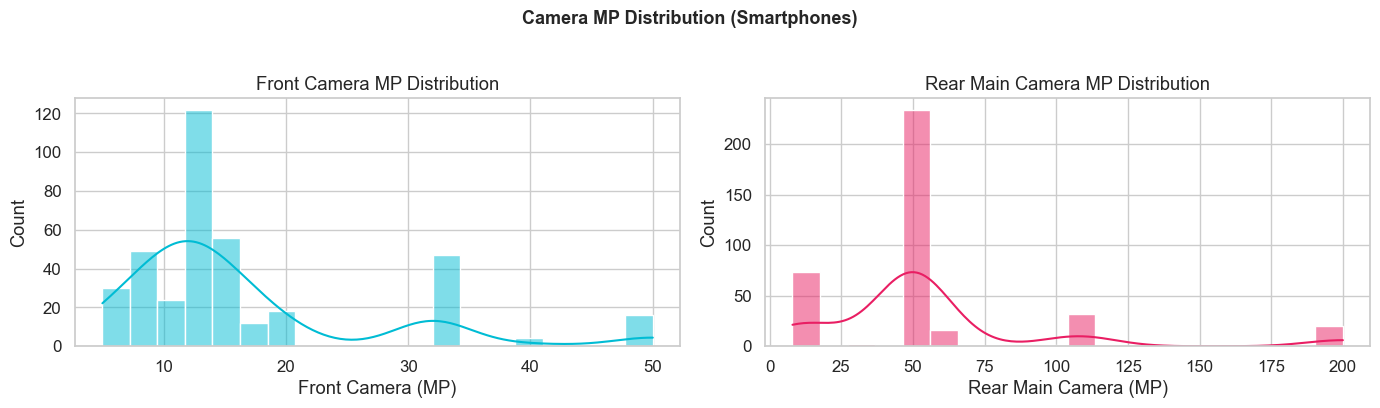

In [328]:
# Seaborn: side-by-side histogram — compare front vs rear MP in one view
cam_df = smartphone_df.dropna(subset=["front_camera_mp", "rear_main_camera_mp"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(
    data=cam_df,
    x="front_camera_mp",
    bins=20,
    kde=True,
    color="#00BCD4",
    ax=axes[0],
)
axes[0].set_title("Front Camera MP Distribution")
axes[0].set_xlabel("Front Camera (MP)")
axes[0].set_ylabel("Count")

sns.histplot(
    data=cam_df,
    x="rear_main_camera_mp",
    bins=20,
    kde=True,
    color="#E91E63",
    ax=axes[1],
)
axes[1].set_title("Rear Main Camera MP Distribution")
axes[1].set_xlabel("Rear Main Camera (MP)")
axes[1].set_ylabel("Count")

plt.suptitle("Camera MP Distribution (Smartphones)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

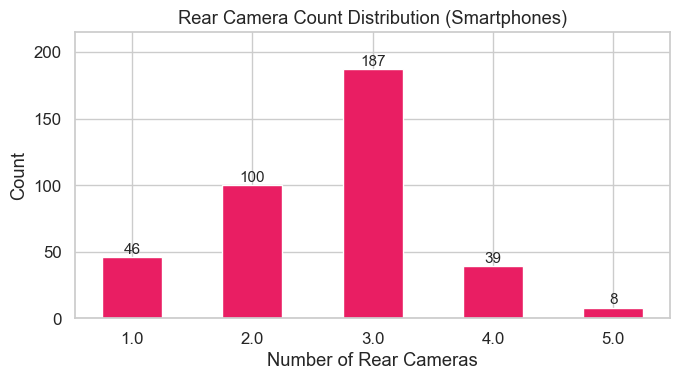

In [329]:
# Matplotlib: bar chart — camera count is discrete (1, 2, 3, 4, 5)
cam_count = (
    smartphone_df["rear_camera_count"]
    .value_counts()
    .sort_index()
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    cam_count.index.astype(str),
    cam_count.values,
    color="#E91E63",
    edgecolor="white",
    width=0.5,
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.5,
        str(int(h)),
        ha="center", va="bottom", fontsize=11,
    )

ax.set_title("Rear Camera Count Distribution (Smartphones)")
ax.set_xlabel("Number of Rear Cameras")
ax.set_ylabel("Count")
ax.set_ylim(0, cam_count.max() * 1.15)
plt.tight_layout()
plt.show()

In [330]:
# Plotly: stacked bar — does higher price = more cameras?
cam_seg = (
    smartphone_df
    .groupby(["rear_camera_count", "price_segment"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    cam_seg,
    x="rear_camera_count",
    y="count",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    barmode="stack",
    title="Rear Camera Count by Price Segment",
    labels={
        "rear_camera_count": "Number of Rear Cameras",
        "count"            : "Count",
        "price_segment"    : "Segment",
    },
    text="count",
)
fig.update_traces(textposition="inside")
fig.update_layout(height=450, xaxis=dict(type="category"))
fig.show()

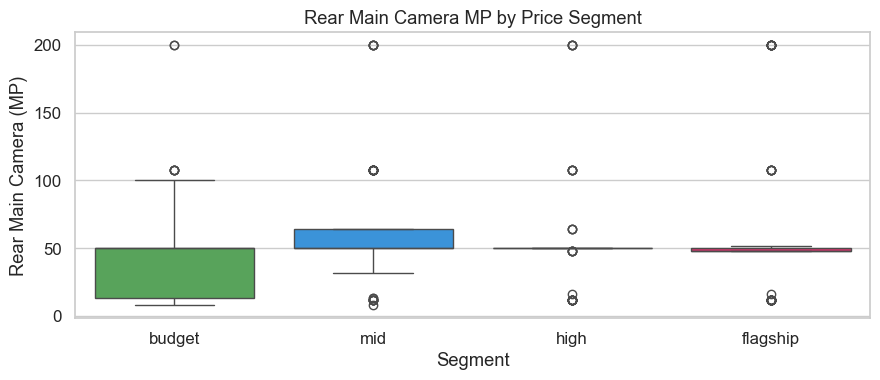

In [331]:
# Seaborn: boxplot — does more expensive = higher MP?
fig, ax = plt.subplots(figsize=(9, 4))

sns.boxplot(
    data=smartphone_df, x="price_segment", y="rear_main_camera_mp",
    order=SEGMENT_ORDER, palette=SEGMENT_COLORS,
    hue="price_segment", legend=False,
    ax=ax,
)

ax.set_title("Rear Main Camera MP by Price Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Rear Main Camera (MP)")
plt.tight_layout()
plt.show()

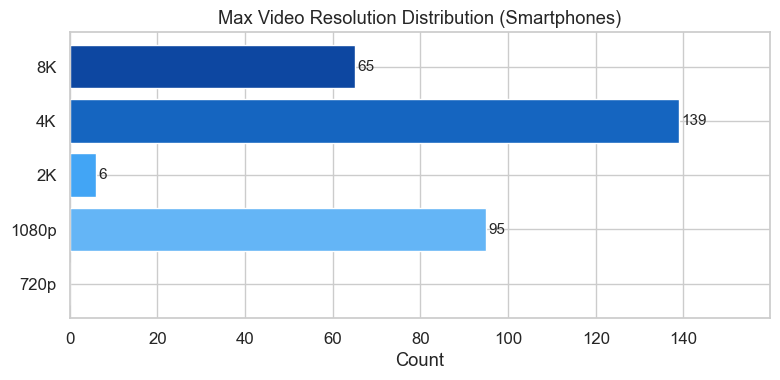

In [332]:
# Matplotlib: horizontal bar — video resolution is ordinal, sort by rank
VIDEO_ORDER = ["720p", "1080p", "2K", "4K", "8K"]

video_counts = (
    smartphone_df["max_video_resolution"]
    .value_counts()
    .reindex(VIDEO_ORDER)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#BDBDBD", "#64B5F6", "#42A5F5", "#1565C0", "#0D47A1"]
bars = ax.barh(
    video_counts.index,
    video_counts.values,
    color=colors,
    edgecolor="white",
)

for bar in bars:
    w = bar.get_width()
    if w > 0:
        ax.text(
            w + 0.5,
            bar.get_y() + bar.get_height() / 2,
            str(int(w)),
            ha="left", va="center", fontsize=11,
        )

ax.set_title("Max Video Resolution Distribution (Smartphones)")
ax.set_xlabel("Count")
ax.set_xlim(0, video_counts.max() * 1.15)
plt.tight_layout()
plt.show()

In [333]:
# Plotly: grouped bar — which segment supports which max resolution?
video_seg = (
    smartphone_df
    .groupby(["max_video_resolution", "price_segment"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    video_seg,
    x="max_video_resolution",
    y="count",
    color="price_segment",
    category_orders={
        "max_video_resolution": VIDEO_ORDER,
        "price_segment"       : SEGMENT_ORDER,
    },
    color_discrete_map=SEGMENT_COLORS,
    barmode="group",
    title="Max Video Resolution by Price Segment",
    labels={
        "max_video_resolution": "Max Video Resolution",
        "count"               : "Count",
        "price_segment"       : "Segment",
    },
    text="count",
)
fig.update_traces(textposition="outside")
fig.update_layout(height=470)
fig.show()

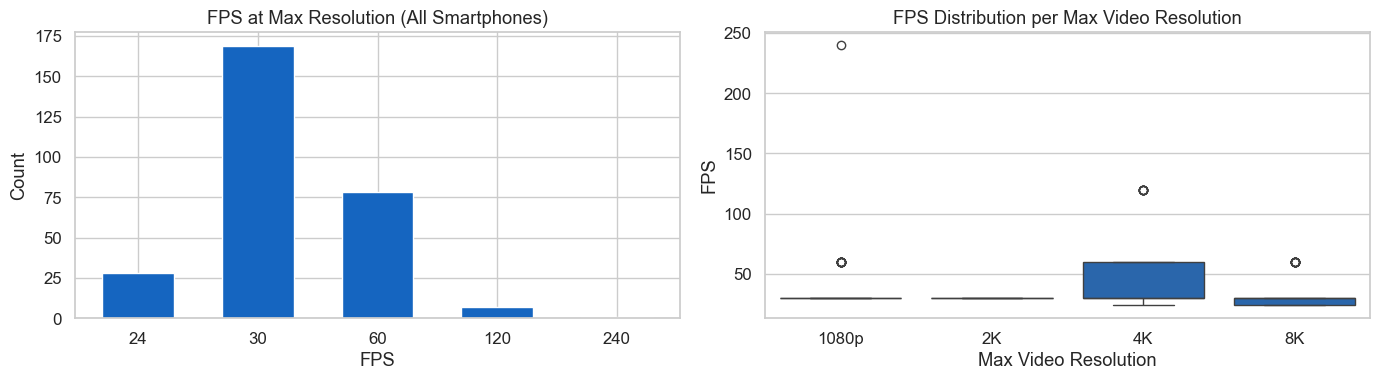

In [334]:
# Seaborn: countplot — FPS is discrete, show frequency of each value
fps_df = smartphone_df.dropna(subset=["fps_at_max_resolution"]).copy()
fps_df["fps_at_max_resolution"] = fps_df["fps_at_max_resolution"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: overall FPS distribution
fps_counts = fps_df["fps_at_max_resolution"].value_counts().sort_index()
axes[0].bar(
    fps_counts.index.astype(str),
    fps_counts.values,
    color="#1565C0",
    edgecolor="white",
    width=0.6,
)
axes[0].set_title("FPS at Max Resolution (All Smartphones)")
axes[0].set_xlabel("FPS")
axes[0].set_ylabel("Count")

# Right: FPS split by max video resolution
sns.boxplot(
    data=fps_df,
    x="max_video_resolution",
    y="fps_at_max_resolution",
    order=[r for r in VIDEO_ORDER if r in fps_df["max_video_resolution"].unique()],
    color="#1565C0",
    ax=axes[1],
)
axes[1].set_title("FPS Distribution per Max Video Resolution")
axes[1].set_xlabel("Max Video Resolution")
axes[1].set_ylabel("FPS")

plt.tight_layout()
plt.show()

In [335]:
# Plotly: scatter — relationship between front and rear MP
# Hover shows product name — useful to spot flagship outliers
fig = px.scatter(
    cam_df,
    x="rear_main_camera_mp",
    y="front_camera_mp",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    hover_data={"product_name": True, "brand": True, "rear_camera_count": True},
    title="Front Camera vs Rear Main Camera MP — by Segment",
    labels={
        "rear_main_camera_mp": "Rear Main Camera (MP)",
        "front_camera_mp"    : "Front Camera (MP)",
        "price_segment"      : "Segment",
    },
    opacity=0.75,
)
fig.update_layout(height=490)
fig.show()

In [336]:
print("=" * 62)
print("CHECK EDA 4 — CAMERA & VIDEO SUMMARY")
print("=" * 62)

print(f"\n  Front camera MP")
fc = smartphone_df["front_camera_mp"].dropna()
print(f"    median={fc.median():.0f} MP  |  min={fc.min():.0f}  max={fc.max():.0f}  "
      f"missing={smartphone_df['front_camera_mp'].isna().sum()}")

print(f"\n  Rear main camera MP")
rc = smartphone_df["rear_main_camera_mp"].dropna()
print(f"    median={rc.median():.0f} MP  |  min={rc.min():.0f}  max={rc.max():.0f}  "
      f"missing={smartphone_df['rear_main_camera_mp'].isna().sum()}")

print(f"\n  Rear camera count")
cc = smartphone_df["rear_camera_count"].dropna()
print(f"    most common={cc.mode()[0]:.0f}  |  max={cc.max():.0f}  "
      f"missing={smartphone_df['rear_camera_count'].isna().sum()}")

print(f"\n  Max video resolution breakdown:")
vc = smartphone_df["max_video_resolution"].value_counts().reindex(VIDEO_ORDER).fillna(0).astype(int)
for res, cnt in vc.items():
    print(f"    {res:<6} : {cnt:>3} phones")

print(f"\n  FPS at max resolution")
fps = smartphone_df["fps_at_max_resolution"].dropna()
print(f"    median={fps.median():.0f}  |  most common={fps.mode()[0]:.0f}  "
      f"missing={smartphone_df['fps_at_max_resolution'].isna().sum()}")

print("=" * 62)

CHECK EDA 4 — CAMERA & VIDEO SUMMARY

  Front camera MP
    median=12 MP  |  min=5  max=50  missing=3

  Rear main camera MP
    median=50 MP  |  min=8  max=200  missing=7

  Rear camera count
    most common=3  |  max=5  missing=7

  Max video resolution breakdown:
    720p   :   0 phones
    1080p  :  95 phones
    2K     :   6 phones
    4K     : 139 phones
    8K     :  65 phones

  FPS at max resolution
    median=30  |  most common=30  missing=104


## Bookmark EDA 5 — Display Analysis

Analyze screen panel types, panel groups, refresh rate,
and resolution distribution across price segments.

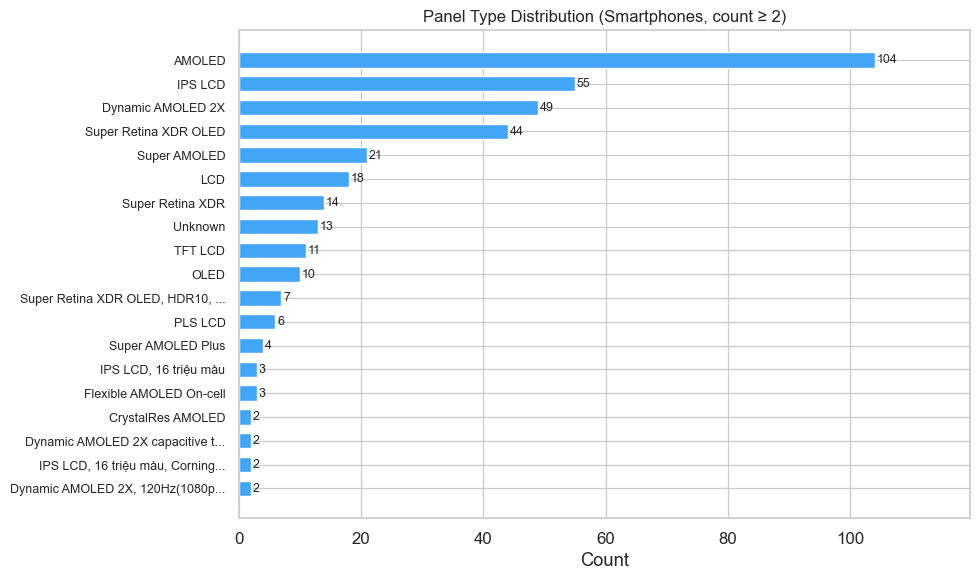

In [337]:
# Truncate long panel names for display only — do not modify the dataframe
MAX_LABEL_LEN = 30

panel_counts = (
    smartphone_df["panel"]
    .value_counts()
    .sort_values(ascending=True)
)

# Truncate labels for display
truncated_labels = [
    label if len(label) <= MAX_LABEL_LEN else label[:MAX_LABEL_LEN] + "..."
    for label in panel_counts.index
]

# Only show panels with count >= 2 to remove noise
mask = panel_counts.values >= 2
panel_counts_filtered = panel_counts[mask]
truncated_labels_filtered = [
    label for label, keep in zip(truncated_labels, mask) if keep
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    truncated_labels_filtered,
    panel_counts_filtered.values,
    color="#42A5F5",
    edgecolor="white",
    height=0.65,
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(int(w)),
        ha="left", va="center", fontsize=9,
    )

ax.set_title("Panel Type Distribution (Smartphones, count ≥ 2)", fontsize=12)
ax.set_xlabel("Count")
ax.set_xlim(0, panel_counts_filtered.max() * 1.15)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

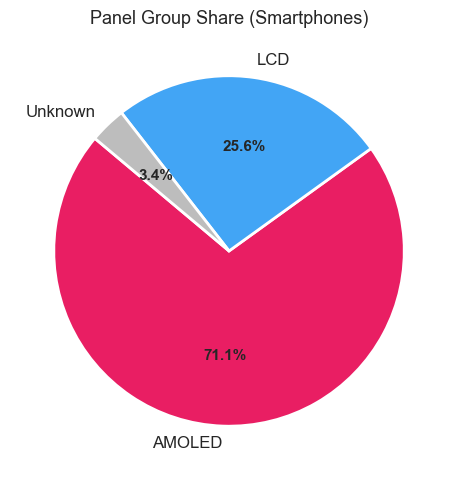

In [338]:
# Matplotlib: pie chart — panel_group has only 2-3 values, pie shows share clearly
panel_group_counts = smartphone_df["panel_group"].value_counts()

PANEL_COLORS = {
    "AMOLED"  : "#E91E63",
    "LCD"     : "#42A5F5",
    "Unknown" : "#BDBDBD",  
}

colors = [PANEL_COLORS.get(p, "#BDBDBD") for p in panel_group_counts.index]

fig, ax = plt.subplots(figsize=(7, 5))

wedges, texts, autotexts = ax.pie(
    panel_group_counts.values,
    labels=panel_group_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")

ax.set_title("Panel Group Share (Smartphones)", fontsize=13)
plt.tight_layout()
plt.show()

In [339]:
# Plotly: 100% stacked bar — show AMOLED vs LCD share within each segment
panel_seg = (
    smartphone_df
    .groupby(["price_segment", "panel_group"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    panel_seg,
    x="price_segment",
    y="count",
    color="panel_group",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=PANEL_COLORS,
    barmode="stack",
    title="Panel Group by Price Segment",
    labels={
        "price_segment": "Segment",
        "count"        : "Count",
        "panel_group"  : "Panel Group",
    },
    text="count",
)
fig.update_traces(textposition="inside")
fig.update_layout(height=450)
fig.show()

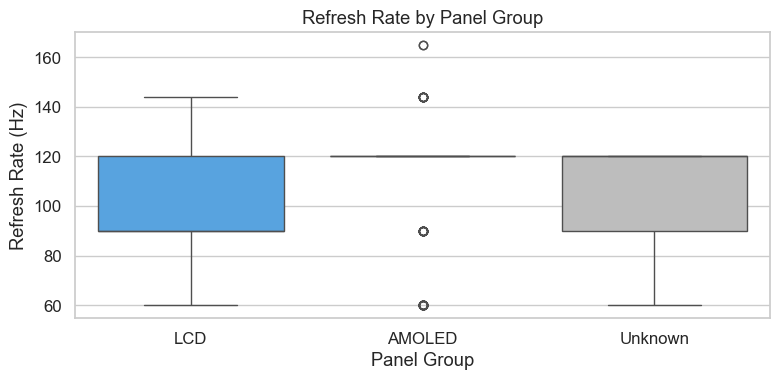

In [340]:
# Seaborn: boxplot — does AMOLED come with higher refresh rate?
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=smartphone_df, x="panel_group", y="refresh_rate_hz",
    order=["LCD", "AMOLED", "Unknown"], 
    palette=PANEL_COLORS,
    hue="panel_group", legend=False,
    ax=ax,
)

ax.set_title("Refresh Rate by Panel Group")
ax.set_xlabel("Panel Group")
ax.set_ylabel("Refresh Rate (Hz)")
plt.tight_layout()
plt.show()

In [341]:
display_df = smartphone_df.dropna(
    subset=["screen_size_inch", "refresh_rate_hz", "panel_group"]
).copy()

fig = px.scatter(
    display_df,
    x="screen_size_inch",
    y="refresh_rate_hz",
    color="panel_group",
    color_discrete_map=PANEL_COLORS,
    facet_col="price_segment",
    category_orders={                        # ← dùng category_orders thay facet_col_order
        "price_segment": SEGMENT_ORDER,
        "panel_group"  : ["LCD", "AMOLED", "Other"],
    },
    hover_data={"product_name": True, "brand": True, "panel": True},
    title="Screen Size vs Refresh Rate — by Panel Group & Segment",
    labels={
        "screen_size_inch": "Screen Size (inch)",
        "refresh_rate_hz" : "Refresh Rate (Hz)",
        "panel_group"     : "Panel Group",
    },
    opacity=0.75,
)
fig.update_layout(height=430)
fig.show()

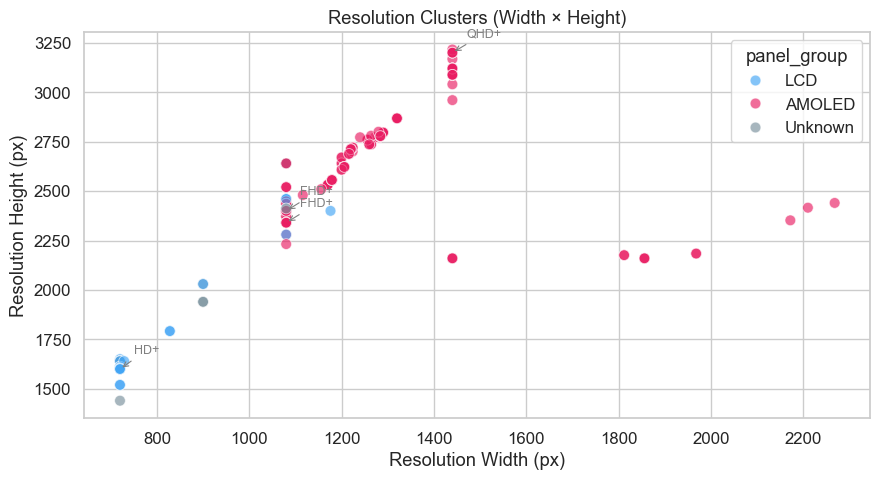

In [342]:
res_df = smartphone_df.dropna(
    subset=["resolution_width", "resolution_height"]
).copy()

# Add "Unknown" to handle panels that could not be grouped
PANEL_COLORS_FULL = {
    "AMOLED" : "#E91E63",
    "LCD"    : "#42A5F5",
    "Other"  : "#BDBDBD",
    "Unknown": "#78909C",   # ← thêm dòng này
}

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=res_df,
    x="resolution_width",
    y="resolution_height",
    hue="panel_group",
    palette=PANEL_COLORS_FULL,   # ← dùng palette đầy đủ
    alpha=0.65,
    s=60,
    ax=ax,
)

COMMON_RES = {
    (720,  1600): "HD+",
    (1080, 2400): "FHD+",
    (1080, 2340): "FHD+",
    (1440, 3200): "QHD+",
}
for (w, h), label in COMMON_RES.items():
    ax.annotate(
        label,
        xy=(w, h),
        xytext=(w + 30, h + 80),
        fontsize=9,
        color="gray",
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
    )

ax.set_title("Resolution Clusters (Width × Height)")
ax.set_xlabel("Resolution Width (px)")
ax.set_ylabel("Resolution Height (px)")
plt.tight_layout()
plt.show()

In [343]:
# Plotly: box + strip combined — total pixels is continuous,
# interactive tooltip helps identify specific high-res outliers
fig = px.box(
    smartphone_df.dropna(subset=["resolution_total_pixels"]),
    x="price_segment",
    y="resolution_total_pixels",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    points="all",
    hover_data={"product_name": True, "panel": True},
    title="Total Pixels by Price Segment",
    labels={
        "price_segment"          : "Segment",
        "resolution_total_pixels": "Total Pixels",
    },
)
fig.update_yaxes(tickformat=",")
fig.update_layout(height=490, showlegend=False)
fig.show()

In [344]:
print("=" * 62)
print("CHECK EDA 5 — DISPLAY SUMMARY")
print("=" * 62)

print(f"\n  Panel type  (top 5):")
for panel, cnt in smartphone_df["panel"].value_counts().head(5).items():
    print(f"    {panel:<25} : {cnt:>3}")

print(f"\n  Panel group breakdown:")
for pg, cnt in smartphone_df["panel_group"].value_counts().items():
    pct = cnt / len(smartphone_df) * 100
    print(f"    {pg:<10} : {cnt:>3}  ({pct:.1f}%)")

print(f"\n  Refresh rate  (most common):")
for hz, cnt in smartphone_df["refresh_rate_hz"].value_counts().head(5).items():
    print(f"    {hz:.0f} Hz : {cnt:>3}")

print(f"\n  Screen size")
ss = smartphone_df["screen_size_inch"].dropna()
print(f"    median={ss.median():.2f}\"  |  "
      f"min={ss.min():.2f}\"  max={ss.max():.2f}\"  "
      f"missing={smartphone_df['screen_size_inch'].isna().sum()}")

print(f"\n  Resolution — total pixels")
px_ = smartphone_df["resolution_total_pixels"].dropna()
print(f"    median={px_.median():,.0f}  |  "
      f"min={px_.min():,.0f}  max={px_.max():,.0f}  "
      f"missing={smartphone_df['resolution_total_pixels'].isna().sum()}")

print("=" * 62)

CHECK EDA 5 — DISPLAY SUMMARY

  Panel type  (top 5):
    AMOLED                    : 104
    IPS LCD                   :  55
    Dynamic AMOLED 2X         :  49
    Super Retina XDR OLED     :  44
    Super AMOLED              :  21

  Panel group breakdown:
    AMOLED     : 275  (71.1%)
    LCD        :  99  (25.6%)
    Unknown    :  13  (3.4%)

  Refresh rate  (most common):
    120 Hz : 249
    90 Hz :  54
    60 Hz :  40
    144 Hz :  14
    165 Hz :   2

  Screen size
    median=6.70"  |  min=5.40"  max=8.12"  missing=1

  Resolution — total pixels
    median=2,604,960  |  min=1,036,800  max=5,533,920  missing=27


## Bookmark EDA 6 — Brand & OS Analysis

Analyze brand market share, OS distribution,
and how brands are distributed across price segments.


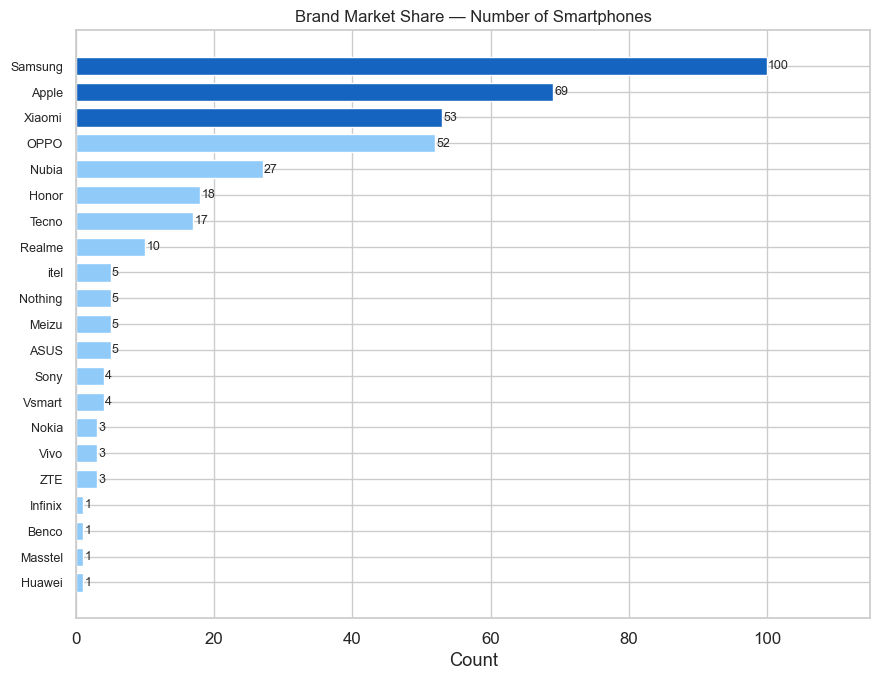

In [345]:
# Matplotlib: horizontal bar — ranked by count, easy to compare market share
brand_counts = (
    smartphone_df["brand"]
    .value_counts()
    .sort_values(ascending=True)
)

# Color top 3 brands differently to highlight market leaders
bar_colors = [
    "#1565C0" if i >= len(brand_counts) - 3 else "#90CAF9"
    for i in range(len(brand_counts))
]

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(
    brand_counts.index,
    brand_counts.values,
    color=bar_colors,
    edgecolor="white",
    height=0.7,
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(int(w)),
        ha="left", va="center", fontsize=9,
    )

ax.set_title("Brand Market Share — Number of Smartphones", fontsize=12)
ax.set_xlabel("Count")
ax.set_xlim(0, brand_counts.max() * 1.15)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

In [346]:
# Plotly: 100% stacked bar — which segment does each brand focus on?
# Only keep brands with >= 5 phones to avoid noise
major_brands = (
    smartphone_df["brand"]
    .value_counts()
    .loc[lambda x: x >= 5]
    .index.tolist()
)

brand_seg_df = (
    smartphone_df[smartphone_df["brand"].isin(major_brands)]
    .groupby(["brand", "price_segment"])
    .size()
    .reset_index(name="count")
)

# Sort brands by total count descending
brand_order_by_count = (
    smartphone_df[smartphone_df["brand"].isin(major_brands)]
    ["brand"].value_counts().index.tolist()
)

fig = px.bar(
    brand_seg_df,
    x="brand",
    y="count",
    color="price_segment",
    category_orders={
        "brand"        : brand_order_by_count,
        "price_segment": SEGMENT_ORDER,
    },
    color_discrete_map=SEGMENT_COLORS,
    barmode="stack",
    title="Brand Distribution by Price Segment (brands with ≥ 5 products)",
    labels={
        "brand"        : "Brand",
        "count"        : "Count",
        "price_segment": "Segment",
    },
    text="count",
)
fig.update_traces(textposition="inside")
fig.update_layout(height=470)
fig.show()

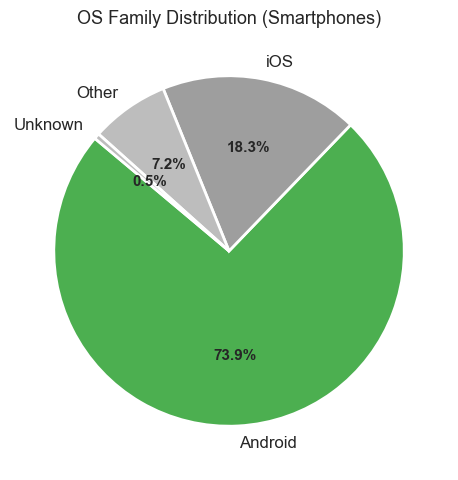

In [347]:
# Matplotlib: pie — OS family has very few values, pie shows dominance clearly
os_counts = smartphone_df["os_family"].value_counts()

OS_COLORS = {
    "Android": "#4CAF50",
    "iOS"    : "#9E9E9E",
    "Other"  : "#BDBDBD",
}
colors = [OS_COLORS.get(os, "#BDBDBD") for os in os_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))

wedges, texts, autotexts = ax.pie(
    os_counts.values,
    labels=os_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")

ax.set_title("OS Family Distribution (Smartphones)", fontsize=13)
plt.tight_layout()
plt.show()

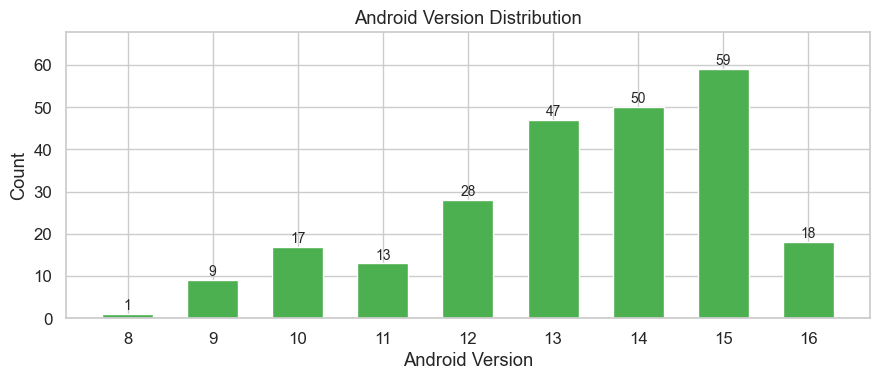

In [348]:
# Matplotlib: bar — Android version is discrete ordinal, bar fits well
android_df = smartphone_df[smartphone_df["os_family"] == "Android"].copy()

android_ver_counts = (
    android_df["os_version"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(
    android_ver_counts.index.astype(str),
    android_ver_counts.values,
    color="#4CAF50",
    edgecolor="white",
    width=0.6,
)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        str(int(h)),
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("Android Version Distribution")
ax.set_xlabel("Android Version")
ax.set_ylabel("Count")
ax.set_ylim(0, android_ver_counts.max() * 1.15)
plt.tight_layout()
plt.show()

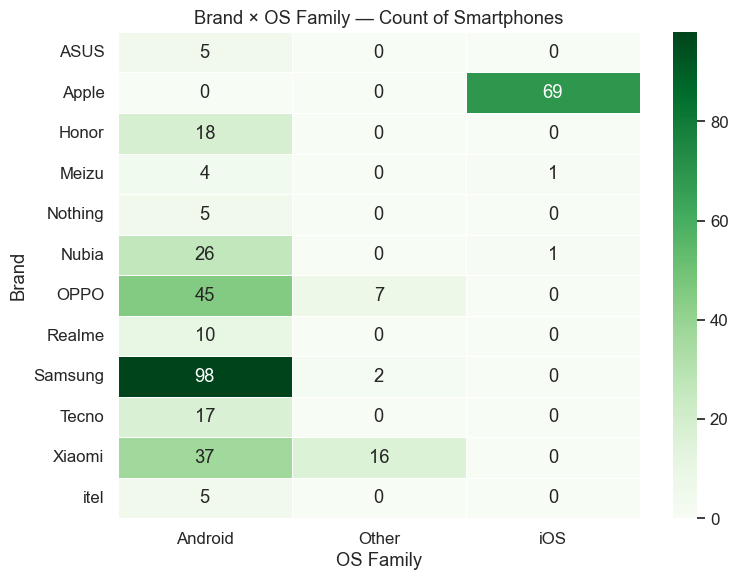

In [349]:
# Seaborn: heatmap — which brand uses which OS?
# Useful to confirm brand-OS mapping (e.g. Apple = iOS only)
brand_os = (
    smartphone_df[smartphone_df["brand"].isin(major_brands)]
    .groupby(["brand", "os_family"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    brand_os,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Brand × OS Family — Count of Smartphones")
ax.set_xlabel("OS Family")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()

In [350]:
# Plotly: interactive bar — rank brands by median price
# Error bars show price spread within each brand
brand_price_stats = (
    smartphone_df[smartphone_df["brand"].isin(major_brands)]
    .groupby("brand")["price_vnd"]
    .agg(median="median", std="std", count="count")
    .sort_values("median", ascending=False)
    .reset_index()
)

fig = px.bar(
    brand_price_stats,
    x="brand",
    y="median",
    error_y="std",
    color="median",
    color_continuous_scale="Blues",
    title="Brand Median Price Ranking (with std error bar)",
    labels={
        "brand" : "Brand",
        "median": "Median Price (VND)",
        "std"   : "Std Dev",
    },
    text=brand_price_stats["median"].apply(lambda x: f"{x/1e6:.1f}M"),
    hover_data={"count": True, "std": True},
)
fig.update_traces(textposition="outside")
fig.update_yaxes(tickformat=",")
fig.update_layout(height=490, coloraxis_showscale=False)
fig.show()

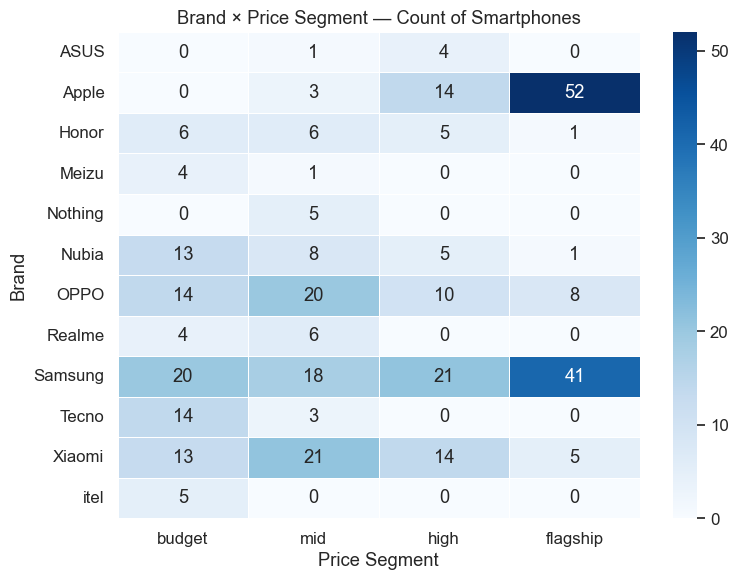

In [351]:
# Seaborn: heatmap — cleaner view of brand positioning across segments
brand_seg_pivot = (
    smartphone_df[smartphone_df["brand"].isin(major_brands)]
    .groupby(["brand", "price_segment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SEGMENT_ORDER)
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    brand_seg_pivot,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Brand × Price Segment — Count of Smartphones")
ax.set_xlabel("Price Segment")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()

In [352]:
print("=" * 62)
print("CHECK EDA 6 — BRAND & OS SUMMARY")
print("=" * 62)

print(f"\n  Total brands         : {smartphone_df['brand'].nunique()}")
print(f"  Major brands (≥ 5)  : {len(major_brands)}")

print(f"\n  Top 5 brands by count:")
for brand, cnt in smartphone_df["brand"].value_counts().head(5).items():
    pct = cnt / len(smartphone_df) * 100
    print(f"    {brand:<15} : {cnt:>3}  ({pct:.1f}%)")

print(f"\n  OS family breakdown:")
for os, cnt in smartphone_df["os_family"].value_counts().items():
    pct = cnt / len(smartphone_df) * 100
    print(f"    {os:<12} : {cnt:>3}  ({pct:.1f}%)")

print(f"\n  Android version (top 5):")
for ver, cnt in (
    android_df["os_version"].dropna().astype(int)
    .value_counts().sort_index(ascending=False).head(5).items()
):
    print(f"    Android {ver} : {cnt:>3}")

print(f"\n  Brand with highest median price:")
top_brand = brand_price_stats.iloc[0]
print(f"    {top_brand['brand']} — {top_brand['median']/1e6:.2f}M VND median")

print(f"\n  Brand with lowest median price:")
bot_brand = brand_price_stats.iloc[-1]
print(f"    {bot_brand['brand']} — {bot_brand['median']/1e6:.2f}M VND median")

print("=" * 62)

CHECK EDA 6 — BRAND & OS SUMMARY

  Total brands         : 21
  Major brands (≥ 5)  : 12

  Top 5 brands by count:
    Samsung         : 100  (25.8%)
    Apple           :  69  (17.8%)
    Xiaomi          :  53  (13.7%)
    OPPO            :  52  (13.4%)
    Nubia           :  27  (7.0%)

  OS family breakdown:
    Android      : 286  (73.9%)
    iOS          :  71  (18.3%)
    Other        :  28  (7.2%)
    Unknown      :   2  (0.5%)

  Android version (top 5):
    Android 16 :  18
    Android 15 :  59
    Android 14 :  50
    Android 13 :  47
    Android 12 :  28

  Brand with highest median price:
    Apple — 24.99M VND median

  Brand with lowest median price:
    itel — 2.99M VND median


## Bookmark EDA 7 — Chip Analysis

Analyze chip brand distribution, chip model frequency,
and how chip brands correlate with price segments.

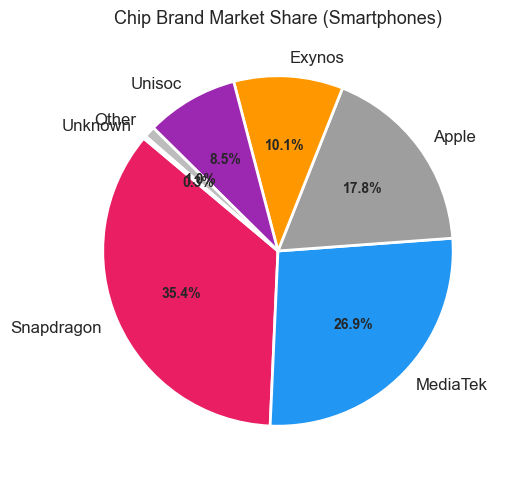

In [353]:
# Matplotlib: pie — chip brand has few values, pie shows market share clearly
chip_brand_counts = smartphone_df["chip_brand"].value_counts()

CHIP_COLORS = {
    "Snapdragon": "#E91E63",
    "MediaTek"  : "#2196F3",
    "Apple"     : "#9E9E9E",
    "Exynos"    : "#FF9800",
    "Unisoc"    : "#9C27B0",
    "Unknown"   : "#78909C",
    "Other"     : "#BDBDBD",
    "ASR"       : "#607D8B",   
}
colors = [CHIP_COLORS.get(c, "#BDBDBD") for c in chip_brand_counts.index]

fig, ax = plt.subplots(figsize=(7, 5))

wedges, texts, autotexts = ax.pie(
    chip_brand_counts.values,
    labels=chip_brand_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")

ax.set_title("Chip Brand Market Share (Smartphones)", fontsize=13)
plt.tight_layout()
plt.show()

In [354]:
# Plotly: 100% stacked bar — which chip brand dominates each segment?
chip_seg = (
    smartphone_df
    .groupby(["price_segment", "chip_brand"])
    .size()
    .reset_index(name="count")
)

# Sort chip brands by total count for consistent legend order
chip_brand_order = smartphone_df["chip_brand"].value_counts().index.tolist()

fig = px.bar(
    chip_seg,
    x="price_segment",
    y="count",
    color="chip_brand",
    category_orders={
        "price_segment": SEGMENT_ORDER,
        "chip_brand"   : chip_brand_order,
    },
    color_discrete_map=CHIP_COLORS,
    barmode="stack",
    title="Chip Brand by Price Segment",
    labels={
        "price_segment": "Segment",
        "count"        : "Count",
        "chip_brand"   : "Chip Brand",
    },
    text="count",
)
fig.update_traces(textposition="inside")
fig.update_layout(height=470)
fig.show()

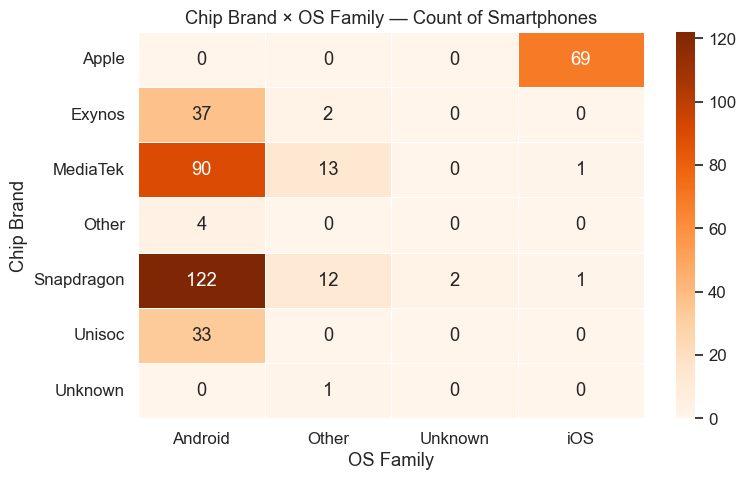

In [355]:
# Seaborn: heatmap — confirm chip brand to OS mapping
# e.g. Apple chip = iOS only, Snapdragon/MediaTek = Android
chip_os = (
    smartphone_df
    .groupby(["chip_brand", "os_family"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    chip_os,
    annot=True,
    fmt="d",
    cmap="Oranges",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Chip Brand × OS Family — Count of Smartphones")
ax.set_xlabel("OS Family")
ax.set_ylabel("Chip Brand")
plt.tight_layout()
plt.show()

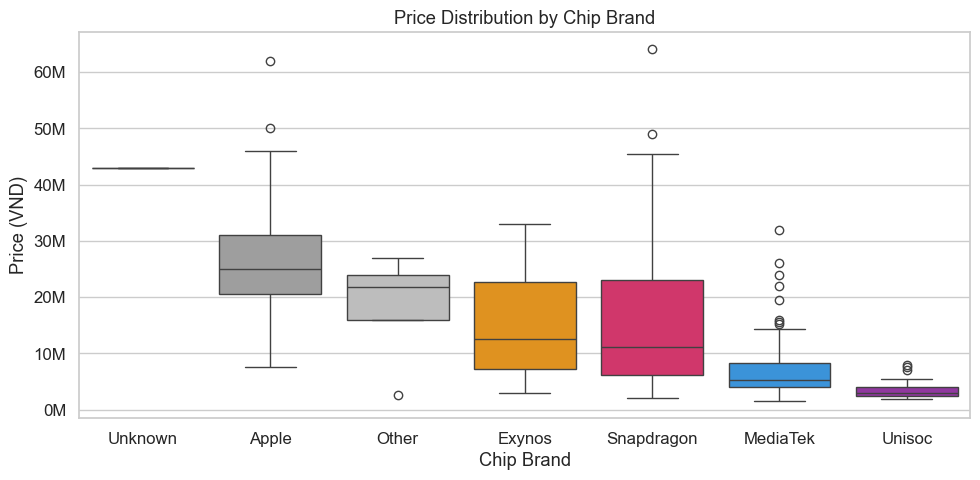

In [356]:
# Add "Unknown" to handle unrecognized chip brands
CHIP_COLORS_FULL = {
    "Snapdragon": "#E91E63",
    "MediaTek"  : "#2196F3",
    "Apple"     : "#9E9E9E",
    "Exynos"    : "#FF9800",
    "Kirin"     : "#4CAF50",
    "Unisoc"    : "#9C27B0",
    "Other"     : "#BDBDBD",
    "Unknown"   : "#78909C",   # ← thêm dòng này
}

chip_price_order = (
    smartphone_df
    .groupby("chip_brand")["price_vnd"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=smartphone_df,
    x="chip_brand",
    y="price_vnd",
    order=chip_price_order,
    hue="chip_brand",          # ← thêm hue để tắt FutureWarning
    palette=CHIP_COLORS_FULL,  # ← dùng palette đầy đủ
    legend=False,              # ← ẩn legend vì hue = x
    ax=ax,
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"{y/1_000_000:.0f}M")
)
ax.set_title("Price Distribution by Chip Brand")
ax.set_xlabel("Chip Brand")
ax.set_ylabel("Price (VND)")
plt.tight_layout()
plt.show()

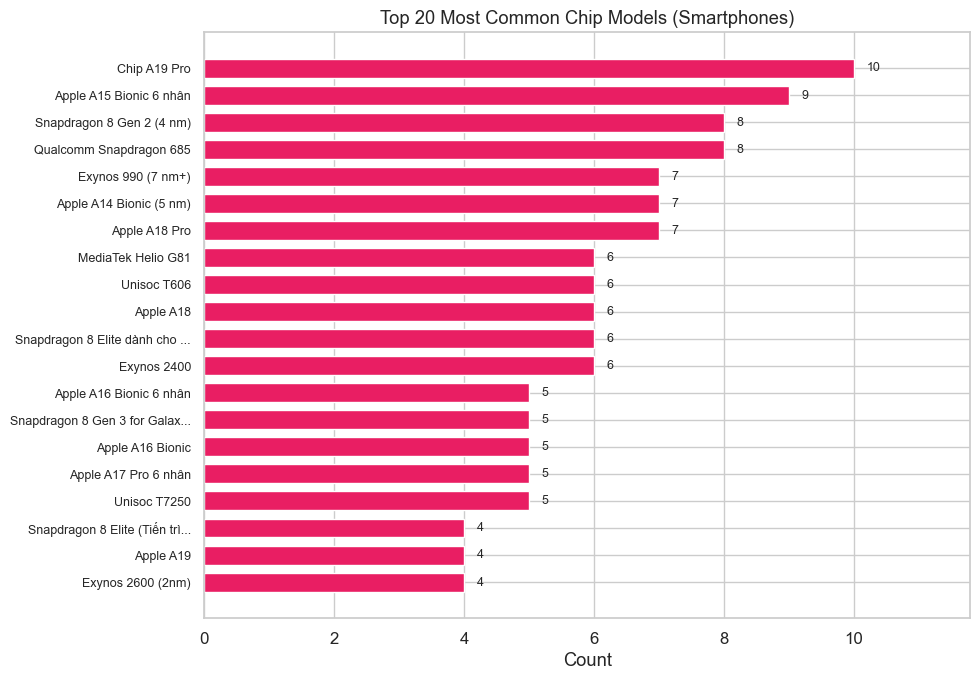

In [357]:
# Matplotlib: horizontal bar — show most common chip models
# Truncate long chip names for readability
MAX_CHIP_LEN = 28

chip_model_counts = (
    smartphone_df["chip_name"]
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

truncated_chip_labels = [
    c if len(c) <= MAX_CHIP_LEN else c[:MAX_CHIP_LEN] + "..."
    for c in chip_model_counts.index
]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    truncated_chip_labels,
    chip_model_counts.values,
    color="#E91E63",
    edgecolor="white",
    height=0.7,
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(int(w)),
        ha="left", va="center", fontsize=9,
    )

ax.set_title("Top 20 Most Common Chip Models (Smartphones)")
ax.set_xlabel("Count")
ax.set_xlim(0, chip_model_counts.max() * 1.18)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

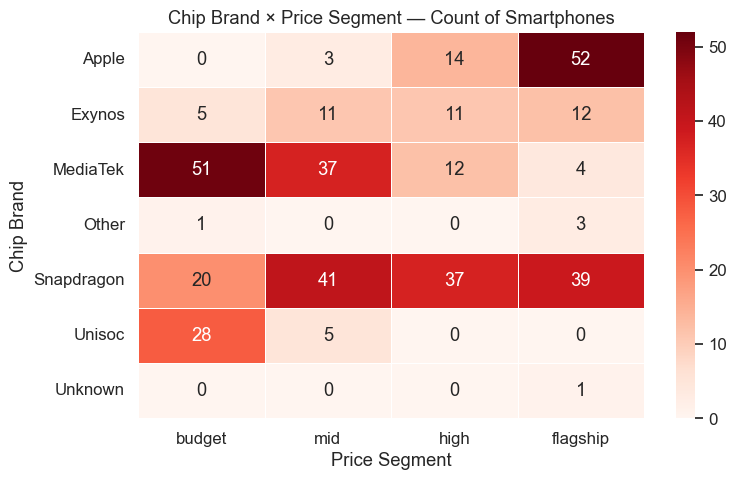

In [358]:
# Seaborn: heatmap — compact view of chip brand positioning per segment
chip_seg_pivot = (
    smartphone_df
    .groupby(["chip_brand", "price_segment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SEGMENT_ORDER)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    chip_seg_pivot,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Chip Brand × Price Segment — Count of Smartphones")
ax.set_xlabel("Price Segment")
ax.set_ylabel("Chip Brand")
plt.tight_layout()
plt.show()

In [359]:
# Plotly: scatter — chip brand vs RAM, sized by storage
# Useful to see if premium chip = higher RAM config
chip_scatter_df = smartphone_df.dropna(
    subset=["ram_gb", "storage_gb", "chip_brand"]
).copy()

fig = px.scatter(
    chip_scatter_df,
    x="price_vnd",
    y="ram_gb",
    color="chip_brand",
    size="storage_gb",
    category_orders={"chip_brand": chip_brand_order},
    color_discrete_map=CHIP_COLORS,
    hover_data={"product_name": True, "chip_name": True, "storage_gb": True},
    title="Chip Brand — Price vs RAM (bubble size = Storage GB)",
    labels={
        "price_vnd" : "Price (VND)",
        "ram_gb"    : "RAM (GB)",
        "chip_brand": "Chip Brand",
    },
    opacity=0.75,
)
fig.update_xaxes(tickformat=",")
fig.update_layout(height=500)
fig.show()

In [360]:
print("=" * 62)
print("CHECK EDA 7 — CHIP ANALYSIS SUMMARY")
print("=" * 62)

print(f"\n  Total unique chip models : {smartphone_df['chip_name'].nunique()}")
print(f"  Total chip brands        : {smartphone_df['chip_brand'].nunique()}")

print(f"\n  Chip brand breakdown:")
for chip, cnt in smartphone_df["chip_brand"].value_counts().items():
    pct = cnt / len(smartphone_df) * 100
    print(f"    {chip:<15} : {cnt:>3}  ({pct:.1f}%)")

print(f"\n  Top 5 most common chip models:")
for chip, cnt in smartphone_df["chip_name"].value_counts().head(5).items():
    label = chip if len(chip) <= 35 else chip[:35] + "..."
    print(f"    {label:<38} : {cnt:>3}")

print(f"\n  Chip brand median price ranking:")
chip_median = (
    smartphone_df
    .groupby("chip_brand")["price_vnd"]
    .median()
    .sort_values(ascending=False)
)
for chip, price in chip_median.items():
    print(f"    {chip:<15} : {price/1e6:.2f}M VND")

print("=" * 62)

CHECK EDA 7 — CHIP ANALYSIS SUMMARY

  Total unique chip models : 206
  Total chip brands        : 7

  Chip brand breakdown:
    Snapdragon      : 137  (35.4%)
    MediaTek        : 104  (26.9%)
    Apple           :  69  (17.8%)
    Exynos          :  39  (10.1%)
    Unisoc          :  33  (8.5%)
    Other           :   4  (1.0%)
    Unknown         :   1  (0.3%)

  Top 5 most common chip models:
    Chip A19 Pro                           :  10
    Apple A15 Bionic 6 nhân                :   9
    Qualcomm Snapdragon 685                :   8
    Snapdragon 8 Gen 2 (4 nm)              :   8
    Exynos 990 (7 nm+)                     :   7

  Chip brand median price ranking:
    Unknown         : 42.99M VND
    Apple           : 24.99M VND
    Other           : 21.72M VND
    Exynos          : 12.56M VND
    Snapdragon      : 11.19M VND
    MediaTek        : 5.34M VND
    Unisoc          : 2.99M VND


## Bookmark EDA 8 — Missing Values Analysis

Analyze missing value patterns across columns,
and understand how missingness relates to phone type and price segment.

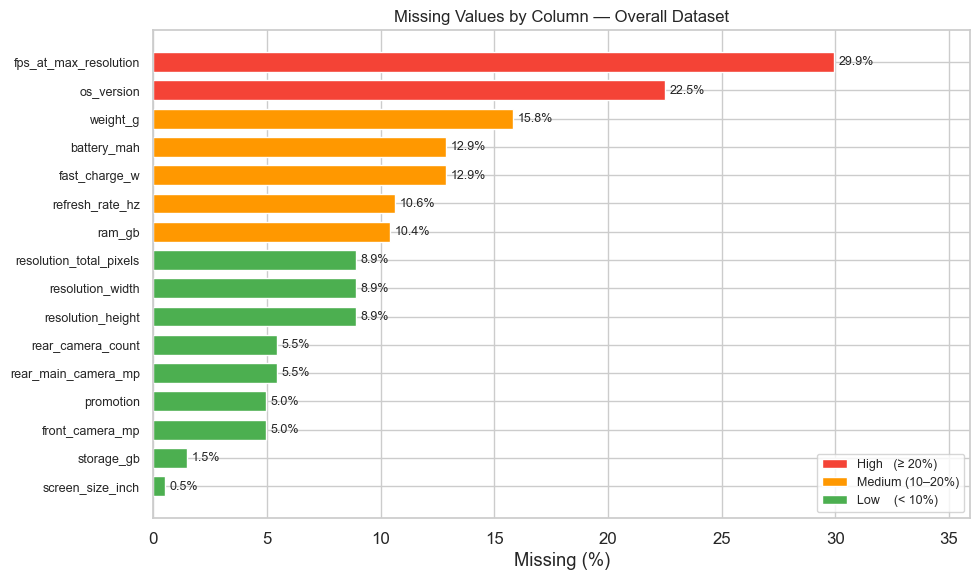

In [361]:
# Matplotlib: horizontal bar — ranked by missing rate, clear and simple
missing_summary = (
    df.isna().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=True)
)

# Color by severity: red > 20%, orange 10-20%, green < 10%
def missing_color(pct):
    if pct >= 20:
        return "#F44336"
    elif pct >= 10:
        return "#FF9800"
    return "#4CAF50"

bar_colors = [missing_color(p) for p in missing_summary["missing_pct"]]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    missing_summary["column"],
    missing_summary["missing_pct"],
    color=bar_colors,
    edgecolor="white",
    height=0.7,
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}%",
        ha="left", va="center", fontsize=9,
    )

# Legend for severity
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#F44336", label="High   (≥ 20%)"),
    Patch(facecolor="#FF9800", label="Medium (10–20%)"),
    Patch(facecolor="#4CAF50", label="Low    (< 10%)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_title("Missing Values by Column — Overall Dataset", fontsize=12)
ax.set_xlabel("Missing (%)")
ax.set_xlim(0, missing_summary["missing_pct"].max() * 1.2)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

In [362]:
# Plotly: grouped bar — feature phones drive most of the missing values
# Compare missing rate between smartphone vs feature_phone


missing_by_type = []

for phone_type, group in df.groupby("phone_type"):
    for col in NUMERIC_COLS:
        pct = group[col].isna().mean() * 100
        if pct > 0:
            missing_by_type.append({
                "column"    : col,
                "phone_type": phone_type,
                "missing_pct": round(pct, 2),
            })

missing_type_df = pd.DataFrame(missing_by_type)

fig = px.bar(
    missing_type_df,
    x="column",
    y="missing_pct",
    color="phone_type",
    barmode="group",
    title="Missing Rate by Column — Smartphone vs Feature Phone",
    labels={
        "column"     : "Column",
        "missing_pct": "Missing (%)",
        "phone_type" : "Phone Type",
    },
    color_discrete_map={
        "smartphone"   : "#2196F3",
        "feature_phone": "#FF9800",
    },
)
fig.update_layout(height=470, xaxis_tickangle=-35)
fig.show()

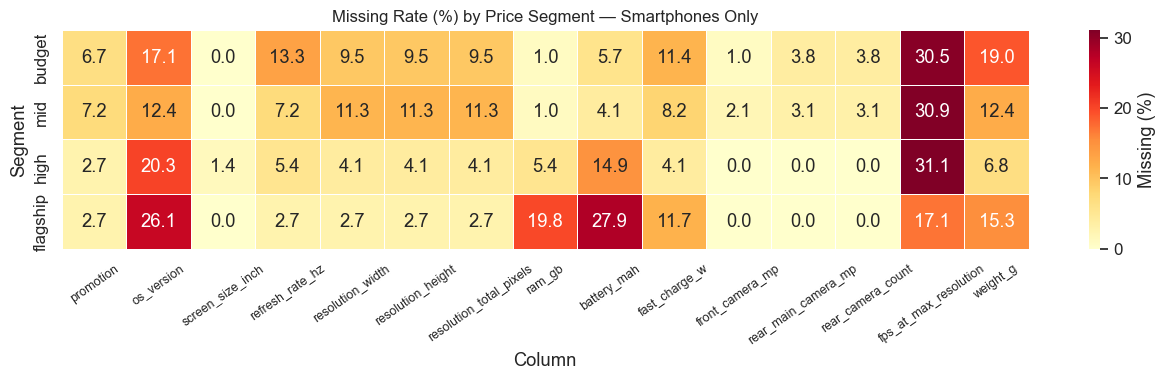

In [363]:
# Seaborn: heatmap — missing rate per column per segment
# Only smartphones, only columns with any missing

missing_seg = (
    smartphone_df
    .groupby("price_segment")
    .apply(lambda g: g.isna().mean() * 100)
    .reindex(SEGMENT_ORDER)
)

# Keep only columns that have at least 1% missing in any segment
cols_with_missing = missing_seg.columns[missing_seg.max() >= 1].tolist()
missing_seg_filtered = missing_seg[cols_with_missing]

fig, ax = plt.subplots(figsize=(13, 4))

sns.heatmap(
    missing_seg_filtered,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Missing (%)"},
    ax=ax,
)

ax.set_title("Missing Rate (%) by Price Segment — Smartphones Only", fontsize=12)
ax.set_xlabel("Column")
ax.set_ylabel("Segment")
ax.tick_params(axis="x", rotation=35, labelsize=9)
plt.tight_layout()
plt.show()

In [364]:
# Plotly: scatter — do cheaper phones have more missing specs?
# Each dot = one phone, y = number of missing numeric fields

smartphone_df["missing_count_per_row"] = smartphone_df[NUMERIC_COLS].isna().sum(axis=1)

fig = px.scatter(
    smartphone_df,
    x="price_vnd",
    y="missing_count_per_row",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    hover_data={"product_name": True, "brand": True},
    title="Missing Fields per Phone vs Price",
    labels={
        "price_vnd"           : "Price (VND)",
        "missing_count_per_row": "Missing Numeric Fields (count)",
        "price_segment"        : "Segment",
    },
    opacity=0.7,
)
fig.update_xaxes(tickformat=",")
fig.update_layout(height=470)
fig.show()

smartphone_df.drop(columns=["missing_count_per_row"], inplace=True)


In [365]:
# Little MCAR test (manual chi-squared approximation)
#
# H0: data is MCAR (missing completely at random)
# Method: compare observed means across missing-pattern groups using chi-squared.
# p < 0.05  -> reject MCAR (data is MAR or MNAR)
# p >= 0.05 -> cannot reject MCAR

import numpy as np
from scipy import stats

def little_mcar_test(data):
    data = data.copy()
    cols = data.columns.tolist()
    pattern = data.isna().apply(lambda r: tuple(r), axis=1)
    groups  = data.groupby(pattern)
    grand_mean = data.mean()
    d2_total = 0.0
    df_total = 0
    for pat, grp in groups:
        observed_cols = [c for c, m in zip(cols, pat) if not m]
        if len(observed_cols) == 0:
            continue
        sub = grp[observed_cols].dropna()
        if len(sub) < 2:
            continue
        n_g  = len(sub)
        mu_g = sub.mean().values
        mu   = grand_mean[observed_cols].values
        cov  = np.cov(sub.values, rowvar=False)
        if cov.ndim == 0:
            cov = np.array([[float(cov)]])
        try:
            diff    = mu_g - mu
            cov_inv = np.linalg.pinv(cov)
            d2_total += n_g * float(diff @ cov_inv @ diff)
            df_total += len(observed_cols)
        except Exception:
            continue
    if df_total == 0:
        return float('nan'), float('nan')
    return d2_total, 1 - stats.chi2.cdf(d2_total, df=df_total)

chi2_stat, p_val = little_mcar_test(smartphone_df[NUMERIC_COLS].copy())

print("=" * 55)
print("LITTLE MCAR TEST")
print("=" * 55)
print(f"  Chi-squared : {chi2_stat:.4f}")
print(f"  p-value     : {p_val:.6f}")
print()
if p_val < 0.05:
    print("  Conclusion: REJECT H0 — data is NOT MCAR.")
    print("  Missingness is likely MAR or MNAR.")
else:
    print("  Conclusion: Cannot reject H0 — data may be MCAR.")
print("=" * 55)


LITTLE MCAR TEST
  Chi-squared : 281634.8184
  p-value     : 0.000000

  Conclusion: REJECT H0 — data is NOT MCAR.
  Missingness is likely MAR or MNAR.


Xử lý các numeric feature có tỉ lệ missing cao:
    "weight_g",
    "battery_mah",
    "fast_charge_w",
    "ram_gb",
    "refresh_rate_hz",
    "fps_at_max_resolution",
    "resolution_width",
    "resolution_height",

In [366]:
import pandas as pd
from scipy.stats import chi2_contingency

# Tạo sẵn biến tương tác chéo (Tổ hợp của Brand và Segment) để dùng chung
smartphone_df["brand_segment"] = (
    smartphone_df["brand"].astype(str)
    + "_"
    + smartphone_df["price_segment"].astype(str)
)

# Danh sách toàn bộ các tính năng cần kiểm tra
features = [
    "weight_g",
    "battery_mah",
    "fast_charge_w",
    "ram_gb",
    "refresh_rate_hz",
    "resolution_width",
    "resolution_height",
    "fps_at_max_resolution",
]

print("=== KIỂM ĐỊNH CHI-SQUARE 3 CHIỀU TOÀN DIỆN ===\n")

for col in features:
    temp_missing_col = f"{col}_missing"

    # 1. Tạo cột báo khuyết dữ liệu (1 = Khuyết, 0 = Đầy đủ)
    smartphone_df[temp_missing_col] = smartphone_df[col].isnull().astype(int)

    # Bỏ qua nếu cột đã đầy đủ 100% dữ liệu
    if smartphone_df[temp_missing_col].nunique() == 1:
        print(f"[{col}] -> Đã đầy đủ 100% dữ liệu. Không cần xử lý khuyết!\n")
        smartphone_df.drop(columns=[temp_missing_col], inplace=True)
        continue

    # 2. Chạy Chi-Square cho Brand (Rời rạc)
    contingency_brand = pd.crosstab(smartphone_df["brand"], smartphone_df[temp_missing_col])
    _, p_b, _, _ = chi2_contingency(contingency_brand)

    # 3. Chạy Chi-Square cho Price Segment (Rời rạc)
    contingency_segment = pd.crosstab(smartphone_df["price_segment"], smartphone_df[temp_missing_col])
    _, p_s, _, _ = chi2_contingency(contingency_segment)

    # 4. Chạy Chi-Square cho Sự tương quan chéo (Brand x Segment)
    contingency_interact = pd.crosstab(smartphone_df["brand_segment"], smartphone_df[temp_missing_col])
    _, p_interact, _, _ = chi2_contingency(contingency_interact)

    # 5. In kết quả 3 chiều
    print(f"Tính năng: {col.upper()}")
    print(f"  -> 1. Chỉ phụ thuộc Brand:      p-value = {p_b:.4e}")
    print(f"  -> 2. Chỉ phụ thuộc Segment:    p-value = {p_s:.4e}")
    print(f"  -> 3. PHỤ THUỘC TƯƠNG TÁC CHÉO:  p-value = {p_interact:.4e}")

    # Logic phân loại tự động nâng cấp cho Hệ thống gợi ý (Mức ý nghĩa p < 0.05)
    if p_interact < 0.05:
        print("  => KẾT LUẬN CUỐI CÙNG: Dữ liệu khuyết theo đặc trưng riêng của từng cặp [Hãng - Khúc giá].")
        print("     (Bắt buộc điền: [Brand + Segment] hoặc dùng KNN đa chiều có chứa Brand và Giá tiền)"
        )
    elif p_b < 0.05 and p_s >= 0.05:
        print("  => KẾT LUẬN CUỐI CÙNG: Chỉ bị chi phối bởi thói quen khai báo của BRAND.")
        print("(Ưu tiên điền: [Brand] -> Toàn cục)")
    elif p_b >= 0.05 and p_s < 0.05:
        print("  => KẾT LUẬN CUỐI CÙNG: Chỉ bị chi phối bởi định vị PHÂN KHÚC GIÁ.")
        print("(Ưu tiên điền: [Segment] -> Toàn cục)")
    else:
        print("  => KẾT LUẬN CUỐI CÙNG: Dữ liệu mất ngẫu nhiên hoàn toàn (MCAR).")
        print("(Điền Global Median/Mode là an toàn)")

    print("-" * 60)

    # Dọn dẹp cột tạm
    smartphone_df.drop(columns=[temp_missing_col], inplace=True)

# Dọn dẹp cột tương tác chéo sau khi kết thúc vòng lặp
smartphone_df.drop(columns=["brand_segment"], inplace=True)

=== KIỂM ĐỊNH CHI-SQUARE 3 CHIỀU TOÀN DIỆN ===

Tính năng: WEIGHT_G
  -> 1. Chỉ phụ thuộc Brand:      p-value = 8.6212e-11
  -> 2. Chỉ phụ thuộc Segment:    p-value = 1.1990e-01
  -> 3. PHỤ THUỘC TƯƠNG TÁC CHÉO:  p-value = 1.0003e-08
  => KẾT LUẬN CUỐI CÙNG: Dữ liệu khuyết theo đặc trưng riêng của từng cặp [Hãng - Khúc giá].
     (Bắt buộc điền: [Brand + Segment] hoặc dùng KNN đa chiều có chứa Brand và Giá tiền)
------------------------------------------------------------
Tính năng: BATTERY_MAH
  -> 1. Chỉ phụ thuộc Brand:      p-value = 1.2957e-16
  -> 2. Chỉ phụ thuộc Segment:    p-value = 3.5719e-07
  -> 3. PHỤ THUỘC TƯƠNG TÁC CHÉO:  p-value = 1.9298e-12
  => KẾT LUẬN CUỐI CÙNG: Dữ liệu khuyết theo đặc trưng riêng của từng cặp [Hãng - Khúc giá].
     (Bắt buộc điền: [Brand + Segment] hoặc dùng KNN đa chiều có chứa Brand và Giá tiền)
------------------------------------------------------------
Tính năng: FAST_CHARGE_W
  -> 1. Chỉ phụ thuộc Brand:      p-value = 8.8508e-19
  -> 2. Chỉ

In [367]:
import pandas as pd
from scipy.stats import chi2_contingency

# Danh sách toàn bộ các tính năng cần kiểm tra
features = [
    'os_version', 'weight_g', 'battery_mah', 'fast_charge_w', 
    'ram_gb', 'refresh_rate_hz', 'resolution_width', 
    'resolution_height', 'fps_at_max_resolution'
]

print("=== KIỂM ĐỊNH CHI-SQUARE TOÀN DIỆN ===\n")

for col in features:
    temp_missing_col = f'{col}_missing'
    
    # 1. Tạo cột báo khuyết dữ liệu (1 = Khuyết, 0 = Đầy đủ)
    smartphone_df[temp_missing_col] = smartphone_df[col].isnull().astype(int)
    
    # Bỏ qua nếu cột đã đầy đủ 100% dữ liệu (tránh lỗi Chi-Square 1 chiều)
    if smartphone_df[temp_missing_col].nunique() == 1:
        print(f"[{col}] -> Đã đầy đủ 100% dữ liệu. Không cần xử lý khuyết!\n")
        smartphone_df.drop(columns=[temp_missing_col], inplace=True)
        continue
    
    # 2. Chạy Chi-Square cho Brand
    contingency_brand = pd.crosstab(smartphone_df['brand'], smartphone_df[temp_missing_col])
    chi2_b, p_b, _, _ = chi2_contingency(contingency_brand)
    
    # 3. Chạy Chi-Square cho Price Segment
    contingency_segment = pd.crosstab(smartphone_df['price_segment'], smartphone_df[temp_missing_col])
    chi2_s, p_s, _, _ = chi2_contingency(contingency_segment)
    
    # 4. In kết quả và Tự động Kết luận
    print(f"Feature: {col.upper()}")
    print(f"  -> Brand Dependency:   p-value = {p_b:.4e}")
    print(f"  -> Segment Dependency: p-value = {p_s:.4e}")
    
    # Phân loại logic toán học (Mức ý nghĩa p < 0.05)
    if p_b < 0.05 and p_s < 0.05:
        print("  => KẾT LUẬN: Phụ thuộc BRAND và SEGMENT.")
    elif p_b < 0.05 and p_s >= 0.05:
        print("  => KẾT LUẬN: Phụ thuộc BRAND.")
    elif p_b >= 0.05 and p_s < 0.05:
        print("  => KẾT LUẬN: Phụ thuộc SEGMENT.")
    else:
        print("  => KẾT LUẬN: Không phụ thuộc")
        
    print("-" * 50)
    
    # Dọn dẹp cột tạm
    smartphone_df.drop(columns=[temp_missing_col], inplace=True)

=== KIỂM ĐỊNH CHI-SQUARE TOÀN DIỆN ===

Feature: OS_VERSION
  -> Brand Dependency:   p-value = 1.2273e-07
  -> Segment Dependency: p-value = 8.1789e-02
  => KẾT LUẬN: Phụ thuộc BRAND.
--------------------------------------------------
Feature: WEIGHT_G
  -> Brand Dependency:   p-value = 8.6212e-11
  -> Segment Dependency: p-value = 1.1990e-01
  => KẾT LUẬN: Phụ thuộc BRAND.
--------------------------------------------------
Feature: BATTERY_MAH
  -> Brand Dependency:   p-value = 1.2957e-16
  -> Segment Dependency: p-value = 3.5719e-07
  => KẾT LUẬN: Phụ thuộc BRAND và SEGMENT.
--------------------------------------------------
Feature: FAST_CHARGE_W
  -> Brand Dependency:   p-value = 8.8508e-19
  -> Segment Dependency: p-value = 2.7582e-01
  => KẾT LUẬN: Phụ thuộc BRAND.
--------------------------------------------------
Feature: RAM_GB
  -> Brand Dependency:   p-value = 9.9039e-15
  -> Segment Dependency: p-value = 2.4419e-08
  => KẾT LUẬN: Phụ thuộc BRAND và SEGMENT.
----------------

In [368]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

print("=== BẮT ĐẦU PIPELINE ĐIỀN KHUYẾT TOÀN DIỆN CHO RECSYS ===")

# ==========================================
# GIAI ĐOẠN 1: DÙNG KNN CHO CỘT FPS (PHỤ THUỘC PHẦN CỨNG PHỨC TẠP)
# ==========================================
print("\n[Giai đoạn 1] Đang xử lý FPS_AT_MAX_RESOLUTION bằng KNN...")
df_knn = smartphone_df.copy()

# Mã hóa hãng thành số để bảo toàn khoảng cách đa chiều
ord_encoder = OrdinalEncoder()
df_knn["brand_encoded"] = ord_encoder.fit_transform(df_knn[["brand"]])

# Sử dụng Brand và Giá tiền số thực làm tọa độ không gian lân cận mượt mà
feature_cols_knn = ["brand_encoded", "price_vnd"]
df_calc_knn = df_knn[feature_cols_knn + ["fps_at_max_resolution"]].copy()

# Chuẩn hóa thang đo về [0, 1] để tránh price_vnd áp đảo brand
scaler = MinMaxScaler()
df_calc_knn[feature_cols_knn] = scaler.fit_transform(
    df_calc_knn[feature_cols_knn].astype(float)
)

# Chạy KNN với K=5 và trọng số theo khoảng cách
imputer_knn = KNNImputer(n_neighbors=5, weights="distance")
imputed_fps = imputer_knn.fit_transform(df_calc_knn)


# Hàm hậu xử lý ép số thực về mốc FPS phần cứng thực tế
def round_to_valid_fps(val):
    if pd.isna(val) or np.isnan(val):
        return np.nan
    valid_fps_milestones = [30, 60, 120, 240]
    return min(valid_fps_milestones, key=lambda x: abs(x - val))


# Cập nhật lại cột FPS sạch vào bảng chính
smartphone_df["fps_at_max_resolution"] = pd.DataFrame(
    imputed_fps, columns=df_calc_knn.columns
)["fps_at_max_resolution"].apply(round_to_valid_fps)

print("=== XỬ LÝ NỚI LỎNG DỮ LIỆU SÓT CHO FPS ===")

# Bước 1: Với những dòng KNN không điền được, hạ cấp xuống điền bằng Trung vị của Phân khúc giá
# (Vì các máy cùng phân khúc giá thường có chip xử lý màn hình tương đương nhau)
smartphone_df['fps_at_max_resolution'] = smartphone_df.groupby('price_segment')['fps_at_max_resolution'].transform(
    lambda x: x.fillna(x.median())
)

# Bước 2: Lưới an toàn cuối cùng (Dành cho trường hợp cả một phân khúc giá nào đó bị trống - dù rất hiếm)
global_fps_median = smartphone_df['fps_at_max_resolution'].median()
smartphone_df['fps_at_max_resolution'] = smartphone_df['fps_at_max_resolution'].fillna(global_fps_median)

# Bước 3: Ép lại về mốc phần cứng một lần cuối cho chắc chắn
def round_to_valid_fps(val):
    import pandas as pd
    import numpy as np
    if pd.isna(val) or np.isnan(val):
        return np.nan
    valid_fps_milestones = [30, 60, 120, 240]
    return min(valid_fps_milestones, key=lambda x: abs(x - val))

smartphone_df['fps_at_max_resolution'] = smartphone_df['fps_at_max_resolution'].apply(round_to_valid_fps)

# Kiểm tra lại số lượng khuyết
still_missing = smartphone_df['fps_at_max_resolution'].isnull().sum()
print(f"-> Số dòng khuyết còn lại sau khi nới lỏng: {still_missing}")

# ==========================================
# GIAI ĐOẠN 2: DÙNG GROUPBY MULTI-LEVEL CHO CÁC BIẾN SỐ TIÊU CHUẨN
# ==========================================
print("\n[Giai đoạn 2] Đang xử lý các biến số chuẩn phần cứng bằng Groupby...")
numeric_features = [
    "weight_g",
    "battery_mah",
    "fast_charge_w",
    "ram_gb",
    "refresh_rate_hz",
    "resolution_width",
    "resolution_height",
]

for col in numeric_features:
    # Bước 1: Điền bằng trung vị của đúng cặp [Hãng - Phân khúc] (Chuẩn theo Chi-Square tương tác)
    smartphone_df[col] = smartphone_df.groupby(["brand", "price_segment"])[
        col
    ].transform(lambda x: x.fillna(x.median()))

    # Bước 2: Hạ cấp dự phòng 1 - Điền theo Phân khúc giá
    smartphone_df[col] = smartphone_df.groupby("price_segment")[col].transform(
        lambda x: x.fillna(x.median())
    )

    # Bước 3: Hạ cấp dự phòng 2 - Điền theo Hãng
    smartphone_df[col] = smartphone_df.groupby("brand")[col].transform(
        lambda x: x.fillna(x.median())
    )

    # Bước 4: Lưới an toàn toàn cục
    smartphone_df[col] = smartphone_df[col].fillna(smartphone_df[col].median())



=== BẮT ĐẦU PIPELINE ĐIỀN KHUYẾT TOÀN DIỆN CHO RECSYS ===

[Giai đoạn 1] Đang xử lý FPS_AT_MAX_RESOLUTION bằng KNN...
=== XỬ LÝ NỚI LỎNG DỮ LIỆU SÓT CHO FPS ===
-> Số dòng khuyết còn lại sau khi nới lỏng: 0

[Giai đoạn 2] Đang xử lý các biến số chuẩn phần cứng bằng Groupby...


In [369]:
# Bước 2: Kiểm tra số dòng khuyết của cột tổng trước khi xử lý
before_missing = smartphone_df['resolution_total_pixels'].isnull().sum()

# Bước 3: Tính toán trực tiếp toán học để lấp đầy giá trị khuyết (chỉ điền vào những chỗ NaN)
calculated_total_pixels = smartphone_df['resolution_width'] * smartphone_df['resolution_height']
smartphone_df['resolution_total_pixels'] = smartphone_df['resolution_total_pixels'].fillna(calculated_total_pixels)

# Bước 4: Kiểm tra lại kết quả
after_missing = smartphone_df['resolution_total_pixels'].isnull().sum()

print(f"-> Kết quả:")
print(f"   + Số dòng khuyết ban đầu: {before_missing}")
print(f"   + Số dòng khuyết sau khi nhân cấu hình: {after_missing}")
print("=== HOÀN THÀNH XỬ LÝ MÀN HÌNH ===")

-> Kết quả:
   + Số dòng khuyết ban đầu: 27
   + Số dòng khuyết sau khi nhân cấu hình: 0
=== HOÀN THÀNH XỬ LÝ MÀN HÌNH ===


In [370]:
print("=" * 62)
print("CHECK EDA 8 — MISSING VALUES SUMMARY AFTER PREPROCESSING")
print("=" * 62)

# --- BƯỚC VÁ LỖI 1: Tự động tính toán missing_summary từ smartphone_df ---
total_rows = len(smartphone_df)
missing_counts = smartphone_df.isnull().sum()
missing_pct = (missing_counts / total_rows) * 100

missing_summary = pd.DataFrame(
    {"column": missing_counts.index, "missing_pct": missing_pct}
)

# Thống kê số lượng cột tổng quan
print(f"\n  Total columns with missing  : {(missing_counts > 0).sum()}")
print(f"  Total columns no missing    : {(missing_counts == 0).sum()}")

# 1. Nhóm HIGH (>= 20%)
print(f"\n  Columns with HIGH missing (≥ 20%):")
high_missing = missing_summary[missing_summary["missing_pct"] >= 20]
if len(high_missing) == 0:
    print("    None")
else:
    for _, row in high_missing.iterrows():
        print(f"    {row['column']:<30} : {row['missing_pct']:.1f}%")

# 2. Nhóm MEDIUM (10% - 20%)
print(f"\n  Columns with MEDIUM missing (10–20%):")
med_missing = missing_summary[
    (missing_summary["missing_pct"] >= 10)
    & (missing_summary["missing_pct"] < 20)
]
if len(med_missing) == 0:
    print("    None")
else:
    for _, row in med_missing.iterrows():
        print(f"    {row['column']:<30} : {row['missing_pct']:.1f}%")

# 3. Nhóm LOW (> 0% và < 10%) -> ĐÃ VÁ LỖI 2: Loại bỏ các cột 0% khuyết
print(f"\n  Columns with LOW missing (0 < % < 10%):")
low_missing = missing_summary[
    (missing_summary["missing_pct"] > 0) & (missing_summary["missing_pct"] < 10)
]
if len(low_missing) == 0:
    print("    None")
else:
    for _, row in low_missing.iterrows():
        print(f"    {row['column']:<30} : {row['missing_pct']:.1f}%")

CHECK EDA 8 — MISSING VALUES SUMMARY AFTER PREPROCESSING

  Total columns with missing  : 6
  Total columns no missing    : 24

  Columns with HIGH missing (≥ 20%):
    None

  Columns with MEDIUM missing (10–20%):
    os_version                     : 19.1%

  Columns with LOW missing (0 < % < 10%):
    promotion                      : 4.9%
    screen_size_inch               : 0.3%
    front_camera_mp                : 0.8%
    rear_main_camera_mp            : 1.8%
    rear_camera_count              : 1.8%


## Bookmark EDA 9 — Correlation Heatmap

Analyze linear correlations between numeric features.
Identify which specs are most related to price,
and spot multicollinearity between features.

In [371]:
# Select numeric columns relevant for correlation analysis
# Exclude rank/index columns and resolution_total_pixels (derived from width × height)
CORR_COLS = [
    "price_vnd",
    "screen_size_inch",
    "refresh_rate_hz",
    "resolution_width",
    "resolution_height",
    "ram_gb",
    "storage_gb",
    "battery_mah",
    "fast_charge_w",
    "front_camera_mp",
    "rear_main_camera_mp",
    "rear_camera_count",
    "weight_g",
    "os_version",
]

corr_df = smartphone_df[CORR_COLS].copy()

# Pearson correlation matrix
corr_matrix = corr_df.corr(method="pearson")

print(f"Correlation matrix shape : {corr_matrix.shape}")
print(f"Columns used             : {len(CORR_COLS)}")

Correlation matrix shape : (14, 14)
Columns used             : 14


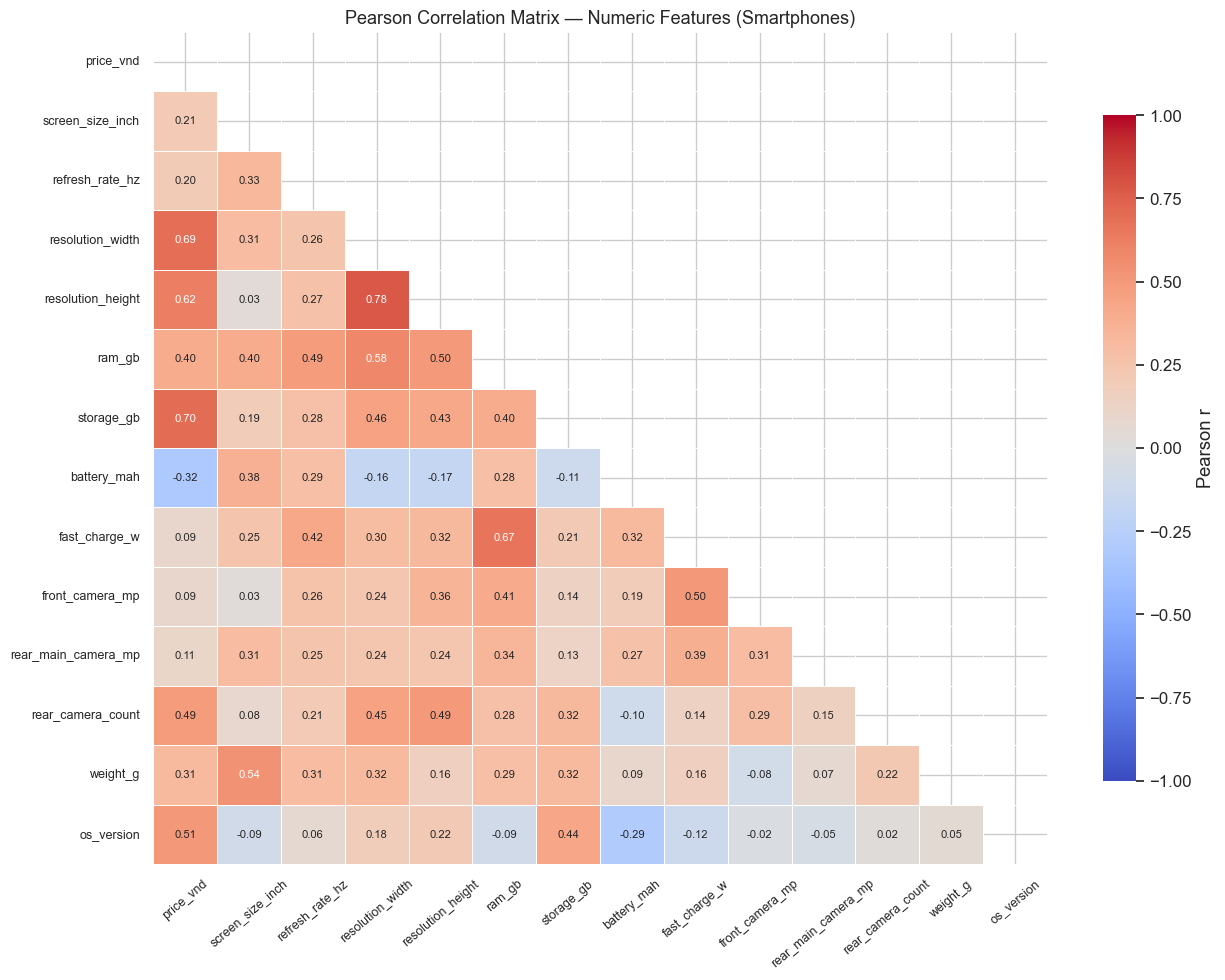

In [372]:
# Seaborn: heatmap — best for showing full correlation matrix at once
fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"label": "Pearson r", "shrink": 0.8},
    ax=ax,
)

ax.set_title("Pearson Correlation Matrix — Numeric Features (Smartphones)", fontsize=13)
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

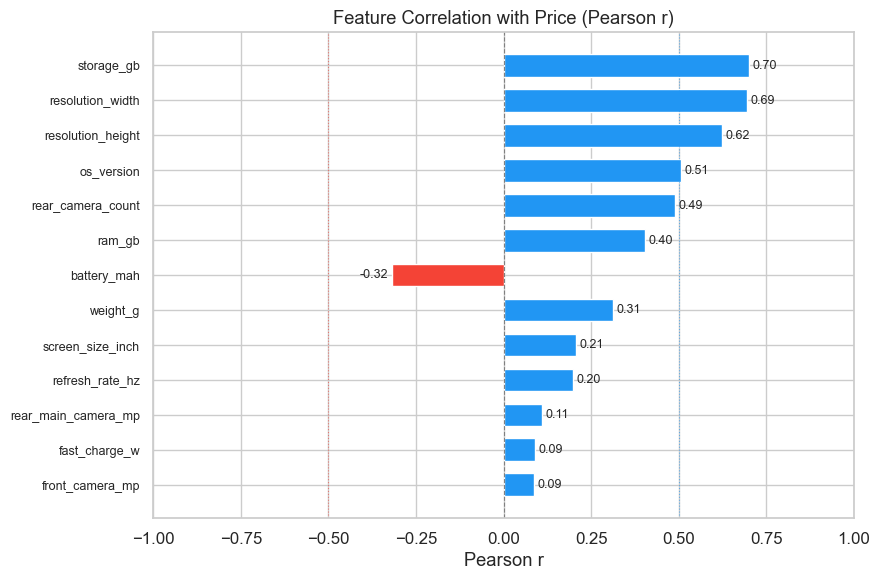

In [373]:
# Matplotlib: horizontal bar — focus on what drives price
# Sort by absolute correlation for easy reading

price_corr = (
    corr_matrix["price_vnd"]
    .drop("price_vnd")
    .sort_values(key=abs, ascending=True)
)

bar_colors = ["#F44336" if v < 0 else "#2196F3" for v in price_corr.values]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    price_corr.index,
    price_corr.values,
    color=bar_colors,
    edgecolor="white",
    height=0.65,
)

for bar in bars:
    w = bar.get_width()
    x_pos = w + 0.01 if w >= 0 else w - 0.01
    ha = "left" if w >= 0 else "right"
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.2f}",
        ha=ha, va="center", fontsize=9,
    )

ax.axvline(x=0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(x=0.5,  color="#2196F3", linewidth=0.8, linestyle=":", alpha=0.6)
ax.axvline(x=-0.5, color="#F44336", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_title("Feature Correlation with Price (Pearson r)")
ax.set_xlabel("Pearson r")
ax.set_xlim(-1, 1)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

In [374]:
# Plotly: interactive bar — show all feature pairs with |r| >= 0.4
# Useful to spot multicollinearity before feature scoring

corr_pairs = (
    corr_matrix
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "r"})
    .assign(abs_r=lambda x: x["r"].abs())
    .query("abs_r >= 0.4")
    .sort_values("abs_r", ascending=True)
)

corr_pairs["pair"] = corr_pairs["feature_a"] + "  ×  " + corr_pairs["feature_b"]

fig = px.bar(
    corr_pairs,
    x="r",
    y="pair",
    orientation="h",
    color="r",
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    range_color=[-1, 1],
    title="Feature Pairs with |r| ≥ 0.4",
    labels={"r": "Pearson r", "pair": "Feature Pair"},
    text=corr_pairs["r"].round(2),
)
fig.update_traces(textposition="outside")
fig.update_layout(
    height=max(400, len(corr_pairs) * 35),
    coloraxis_colorbar=dict(title="r"),
    xaxis=dict(range=[-1, 1]),
)
fig.show()

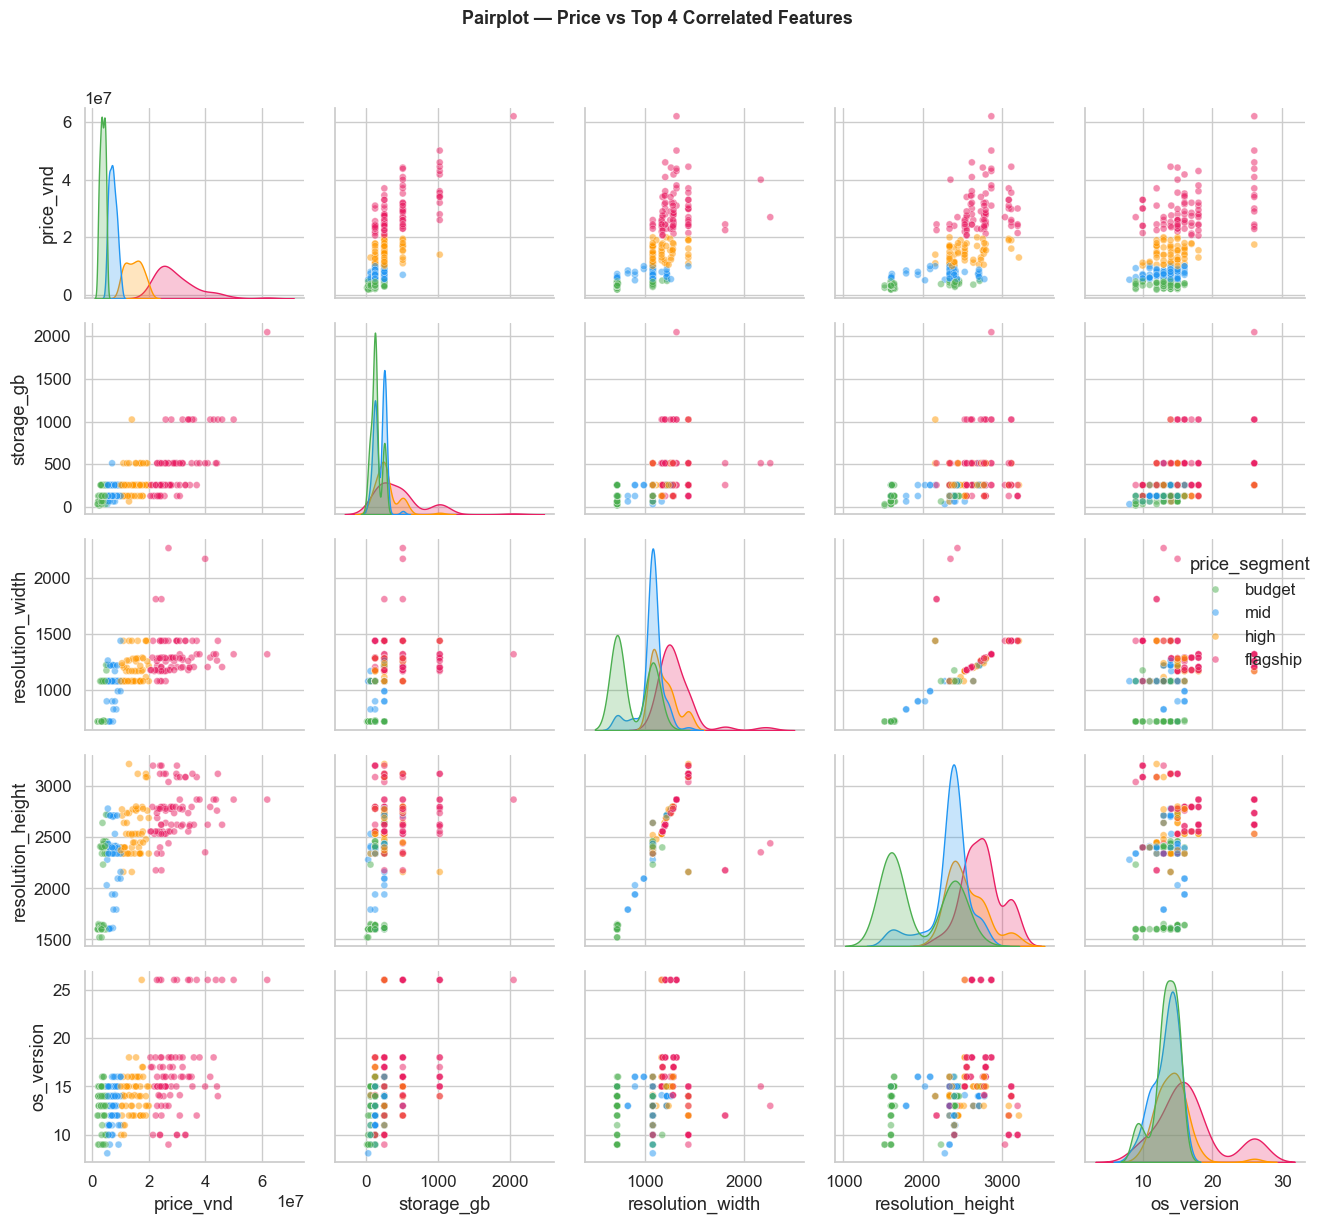

In [375]:
# Seaborn: pairplot on top 4 features most correlated with price
# Shows scatter + distribution at once — best for regression intuition

top_4_features = (
    corr_matrix["price_vnd"]
    .drop("price_vnd")
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

pair_cols = ["price_vnd"] + top_4_features

pair_df = smartphone_df[pair_cols + ["price_segment"]].dropna().copy()

g = sns.pairplot(
    pair_df,
    hue="price_segment",
    hue_order=SEGMENT_ORDER,
    palette=SEGMENT_COLORS,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 25},
    height=2.4,
)

g.figure.suptitle(
    "Pairplot — Price vs Top 4 Correlated Features",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

In [376]:
# Plotly: 3D scatter — visualize RAM, storage, price together
# More informative than 2D for memory-price relationship

scatter_3d_df = smartphone_df.dropna(
    subset=["ram_gb", "storage_gb", "price_vnd"]
).copy()

fig = px.scatter_3d(
    scatter_3d_df,
    x="ram_gb",
    y="storage_gb",
    z="price_vnd",
    color="price_segment",
    category_orders={"price_segment": SEGMENT_ORDER},
    color_discrete_map=SEGMENT_COLORS,
    hover_data={"product_name": True, "brand": True, "chip_brand": True},
    title="RAM × Storage × Price — 3D View",
    labels={
        "ram_gb"    : "RAM (GB)",
        "storage_gb": "Storage (GB)",
        "price_vnd" : "Price (VND)",
    },
    opacity=0.75,
    size_max=6,
)
fig.update_layout(height=560)
fig.show()

In [377]:
print("=" * 65)
print("CHECK EDA 9 — CORRELATION SUMMARY")
print("=" * 65)

price_corr_sorted = (
    corr_matrix["price_vnd"]
    .drop("price_vnd")
    .sort_values(key=abs, ascending=False)
)

print(f"\n  Features ranked by |correlation with price|:")
for feat, r in price_corr_sorted.items():
    bar  = "█" * int(abs(r) * 20)
    sign = "+" if r >= 0 else "-"
    print(f"    {feat:<25} : {sign}{abs(r):.2f}  {bar}")

print(f"\n  Strong positive pairs (r ≥ 0.6):")
strong_pos = corr_pairs[corr_pairs["r"] >= 0.6][["pair", "r"]]
if len(strong_pos) == 0:
    print("    None")
else:
    for _, row in strong_pos.iterrows():
        print(f"    {row['pair']:<45} : {row['r']:.2f}")

print(f"\n  Strong negative pairs (r ≤ -0.6):")
strong_neg = corr_pairs[corr_pairs["r"] <= -0.6][["pair", "r"]]
if len(strong_neg) == 0:
    print("    None")
else:
    for _, row in strong_neg.iterrows():
        print(f"    {row['pair']:<45} : {row['r']:.2f}")

print(f"\n  Top 4 features most correlated with price:")
for feat, r in price_corr_sorted.head(4).items():
    print(f"    {feat:<25} : r = {r:.2f}")

print("=" * 65)

CHECK EDA 9 — CORRELATION SUMMARY

  Features ranked by |correlation with price|:
    storage_gb                : +0.70  ██████████████
    resolution_width          : +0.69  █████████████
    resolution_height         : +0.62  ████████████
    os_version                : +0.51  ██████████
    rear_camera_count         : +0.49  █████████
    ram_gb                    : +0.40  ████████
    battery_mah               : -0.32  ██████
    weight_g                  : +0.31  ██████
    screen_size_inch          : +0.21  ████
    refresh_rate_hz           : +0.20  ███
    rear_main_camera_mp       : +0.11  ██
    fast_charge_w             : +0.09  █
    front_camera_mp           : +0.09  █

  Strong positive pairs (r ≥ 0.6):
    resolution_height  ×  price_vnd               : 0.62
    fast_charge_w  ×  ram_gb                      : 0.67
    resolution_width  ×  price_vnd                : 0.69
    storage_gb  ×  price_vnd                      : 0.70
    resolution_height  ×  resolution_width   

In [378]:
from pathlib import Path
output_path = Path("../../data/processed/phone_specs_preprocessed_v2.csv")
smartphone_df.to_csv(output_path, index=False, encoding="utf-8-sig")